# Combined Model Chromatin Deconvolution

In [602]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from src.DG1Analysis import DG1Analysis

output_directory = 'output/prototype_pipeline_subset'
dg1_analysis = DG1Analysis(output_directory)


Loading configs from replication runs:  output/prototype_pipeline_subset/single_replication/
Shifting mu0, gamma1, and gamma2, for alpha...


# Analysis of chromatin deconvolution

1. Start with sanity checks, show that we are able to load any of the deconvolution windows

In [3]:
dg1_analysis.load_chromatin_measures()

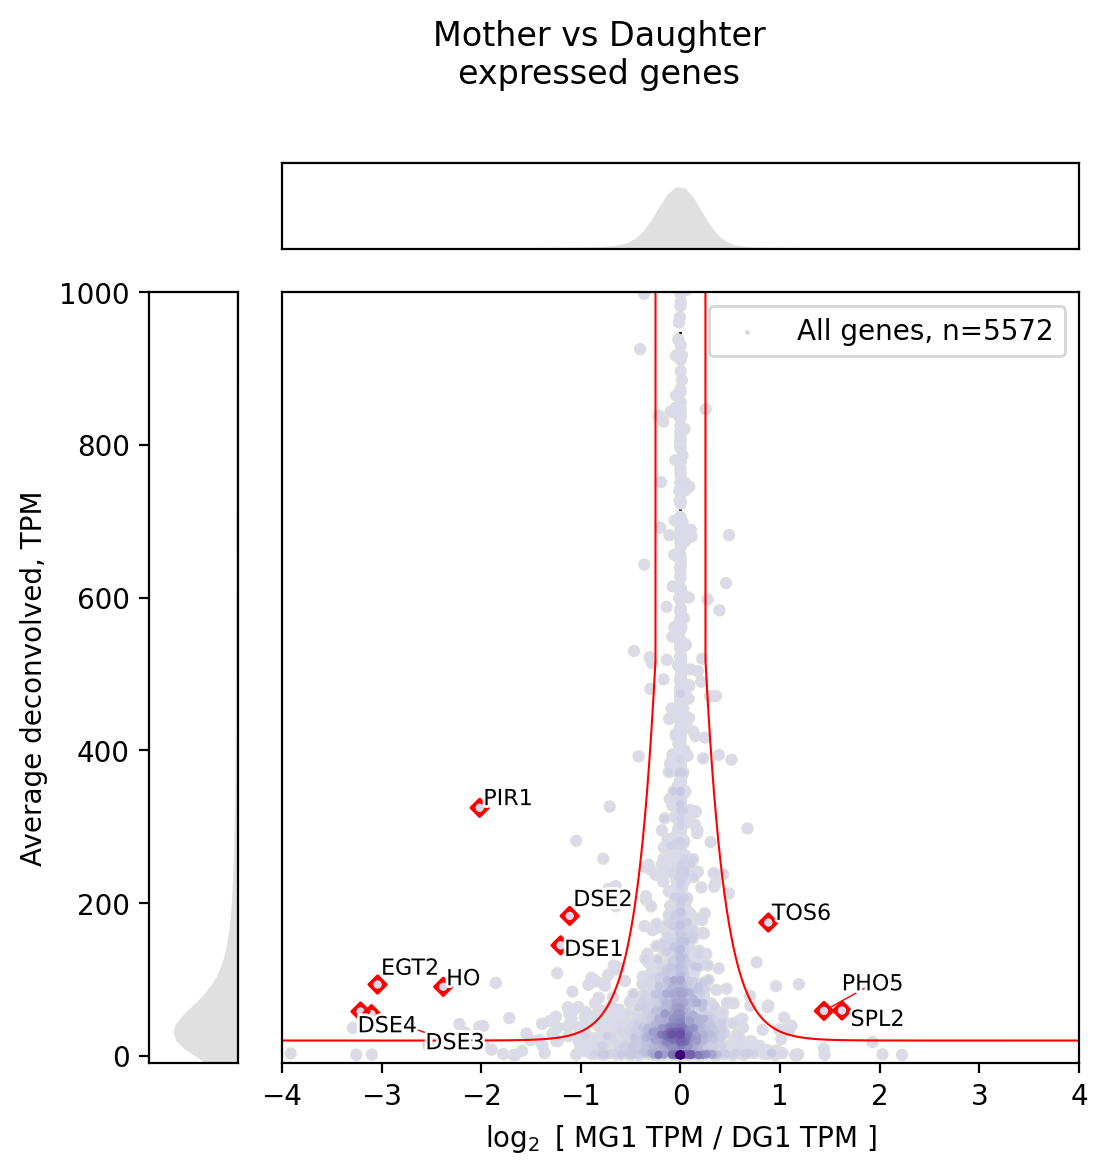

In [240]:
from pipeline.expression_analysis import ExpressionAnalysis

analysis = ExpressionAnalysis(output_directory)
analysis.plot_volcano_cg1_dg1(genes_callout=['DSE1', 'DSE2', 'DSE3', 'DSE4', 'PHO5',
    'HO', 'SPL2', 'PIR1', 'EGT2', 'TOS6'])


In [6]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genome_analysis = GenomeDeconvolutionAnalysis(outdir=
    f"{output_directory}/chromatin_deconvolution/deconvolution_data")

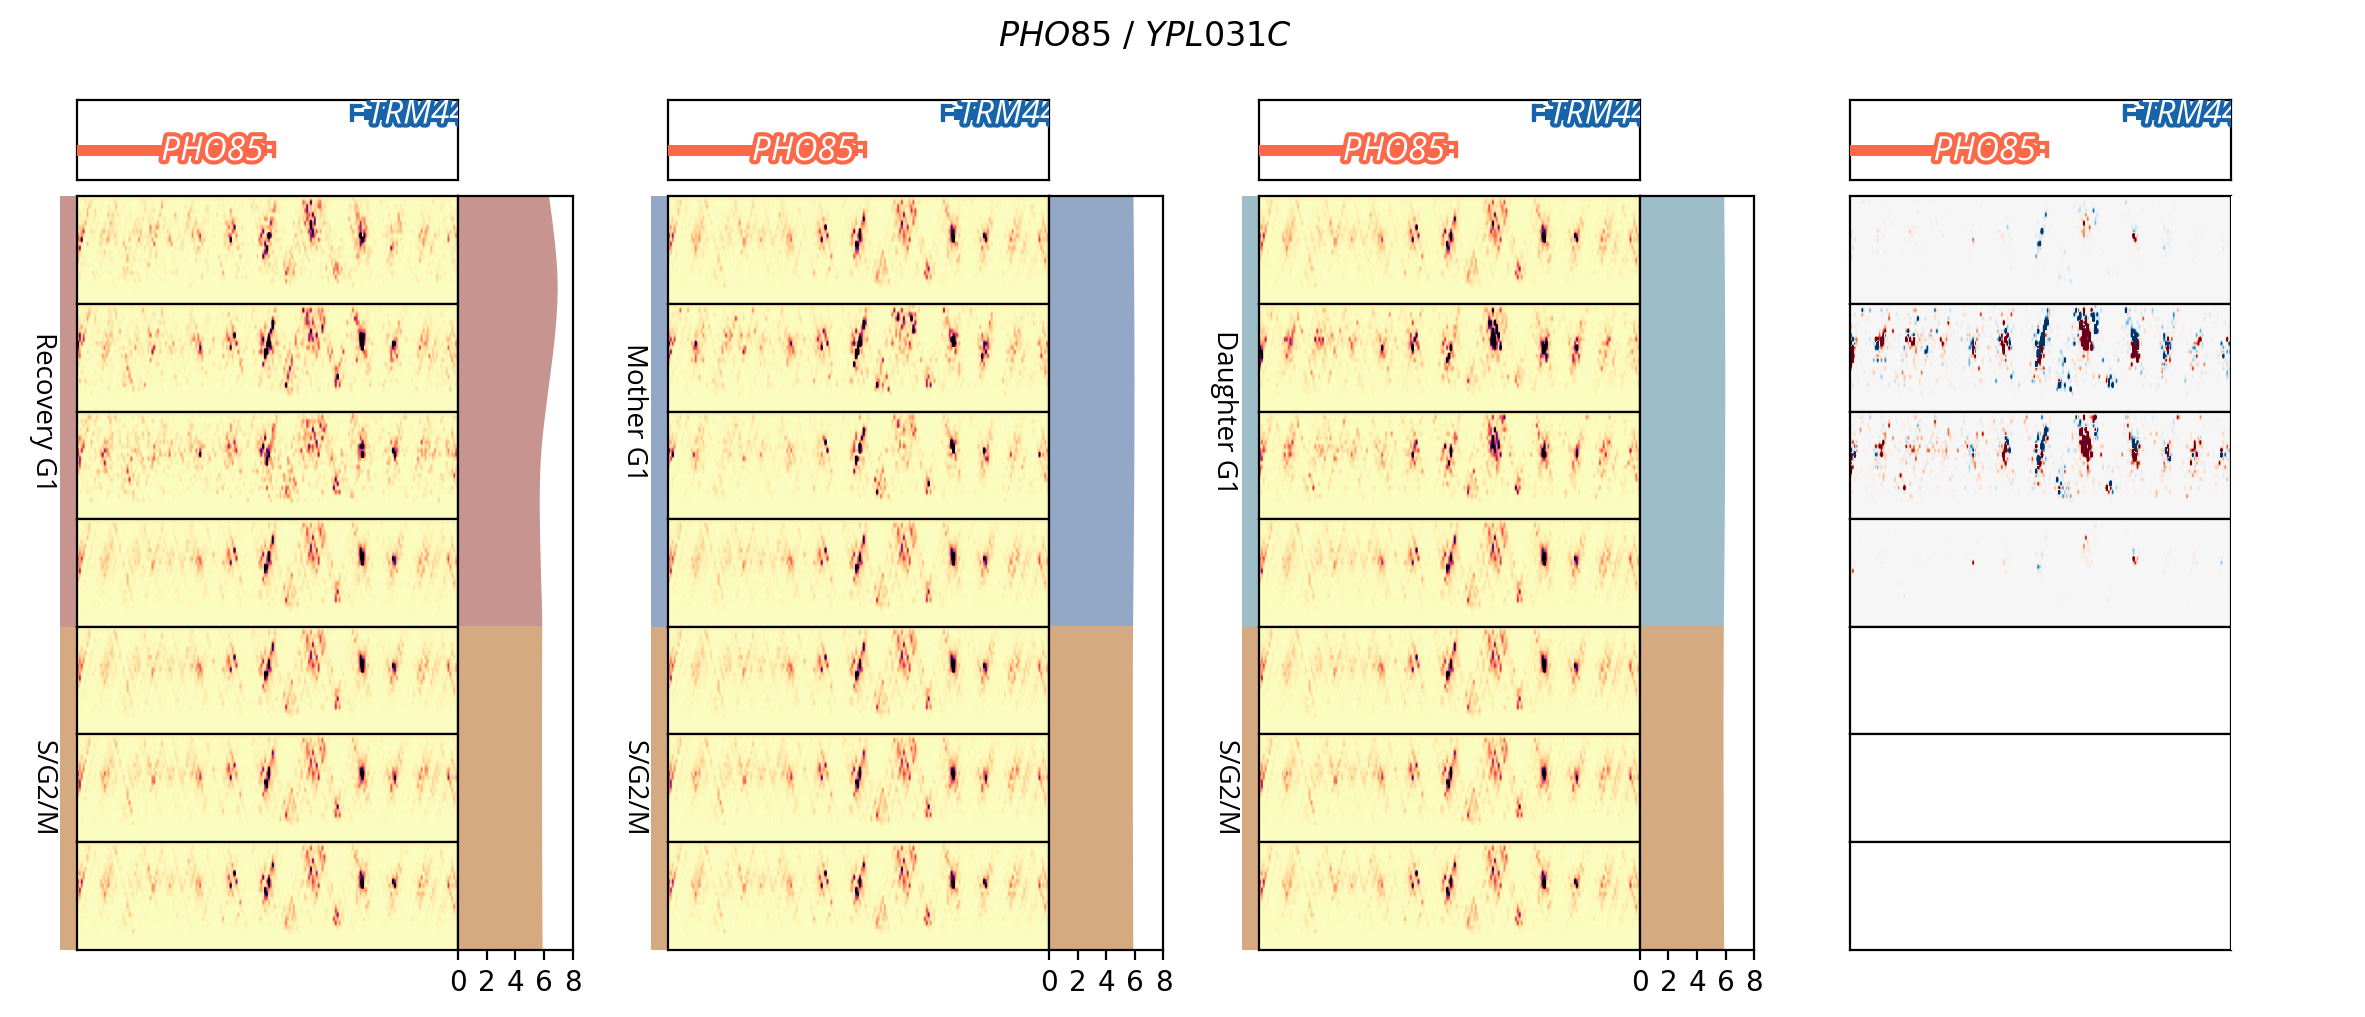

In [9]:
config1 = analysis.config1
fig = genome_analysis.plot_gene('PHO85', config1, analysis)

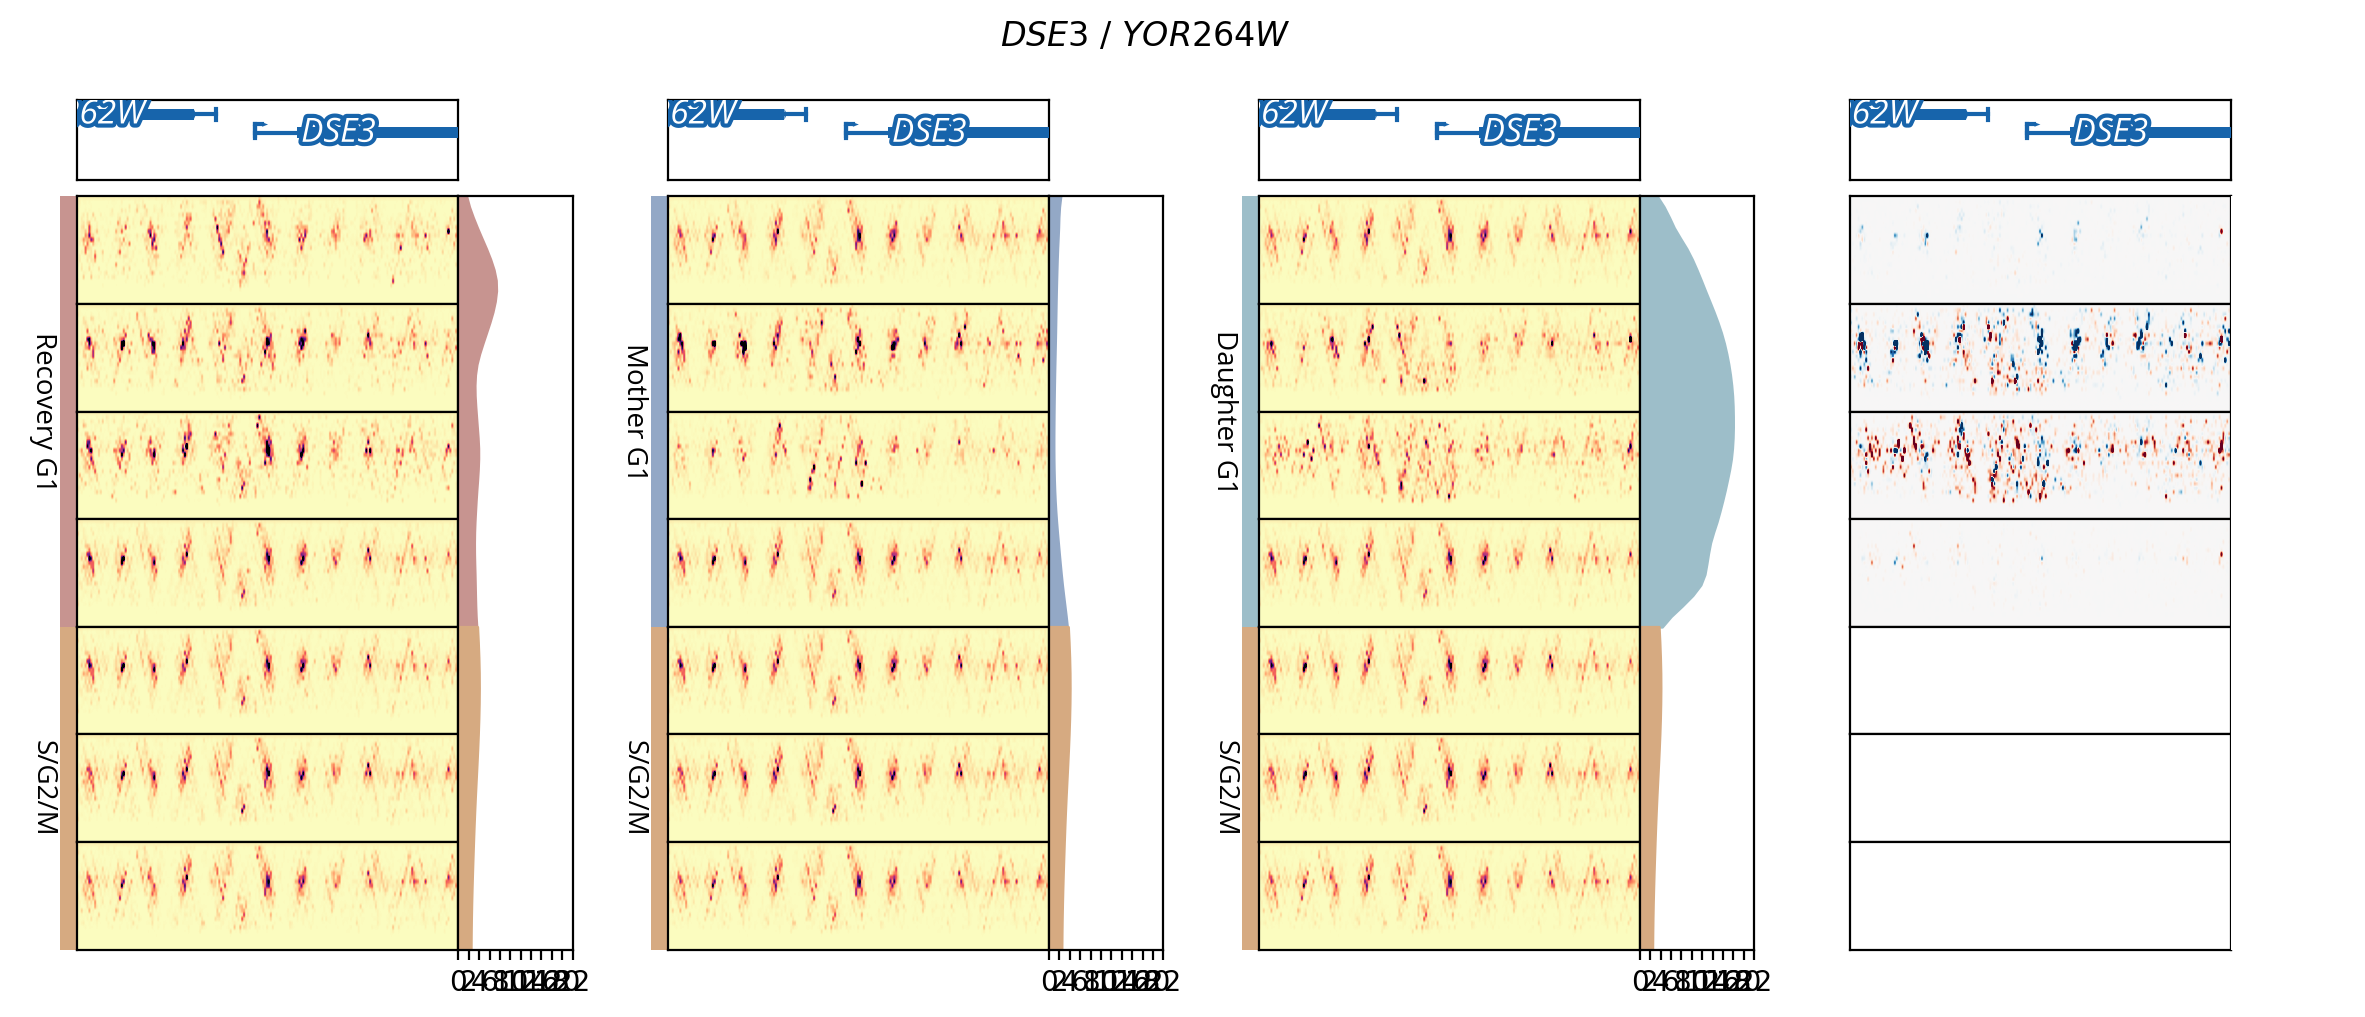

In [10]:
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs()

fig = genome_analysis.plot_gene('DSE3', config1, analysis)

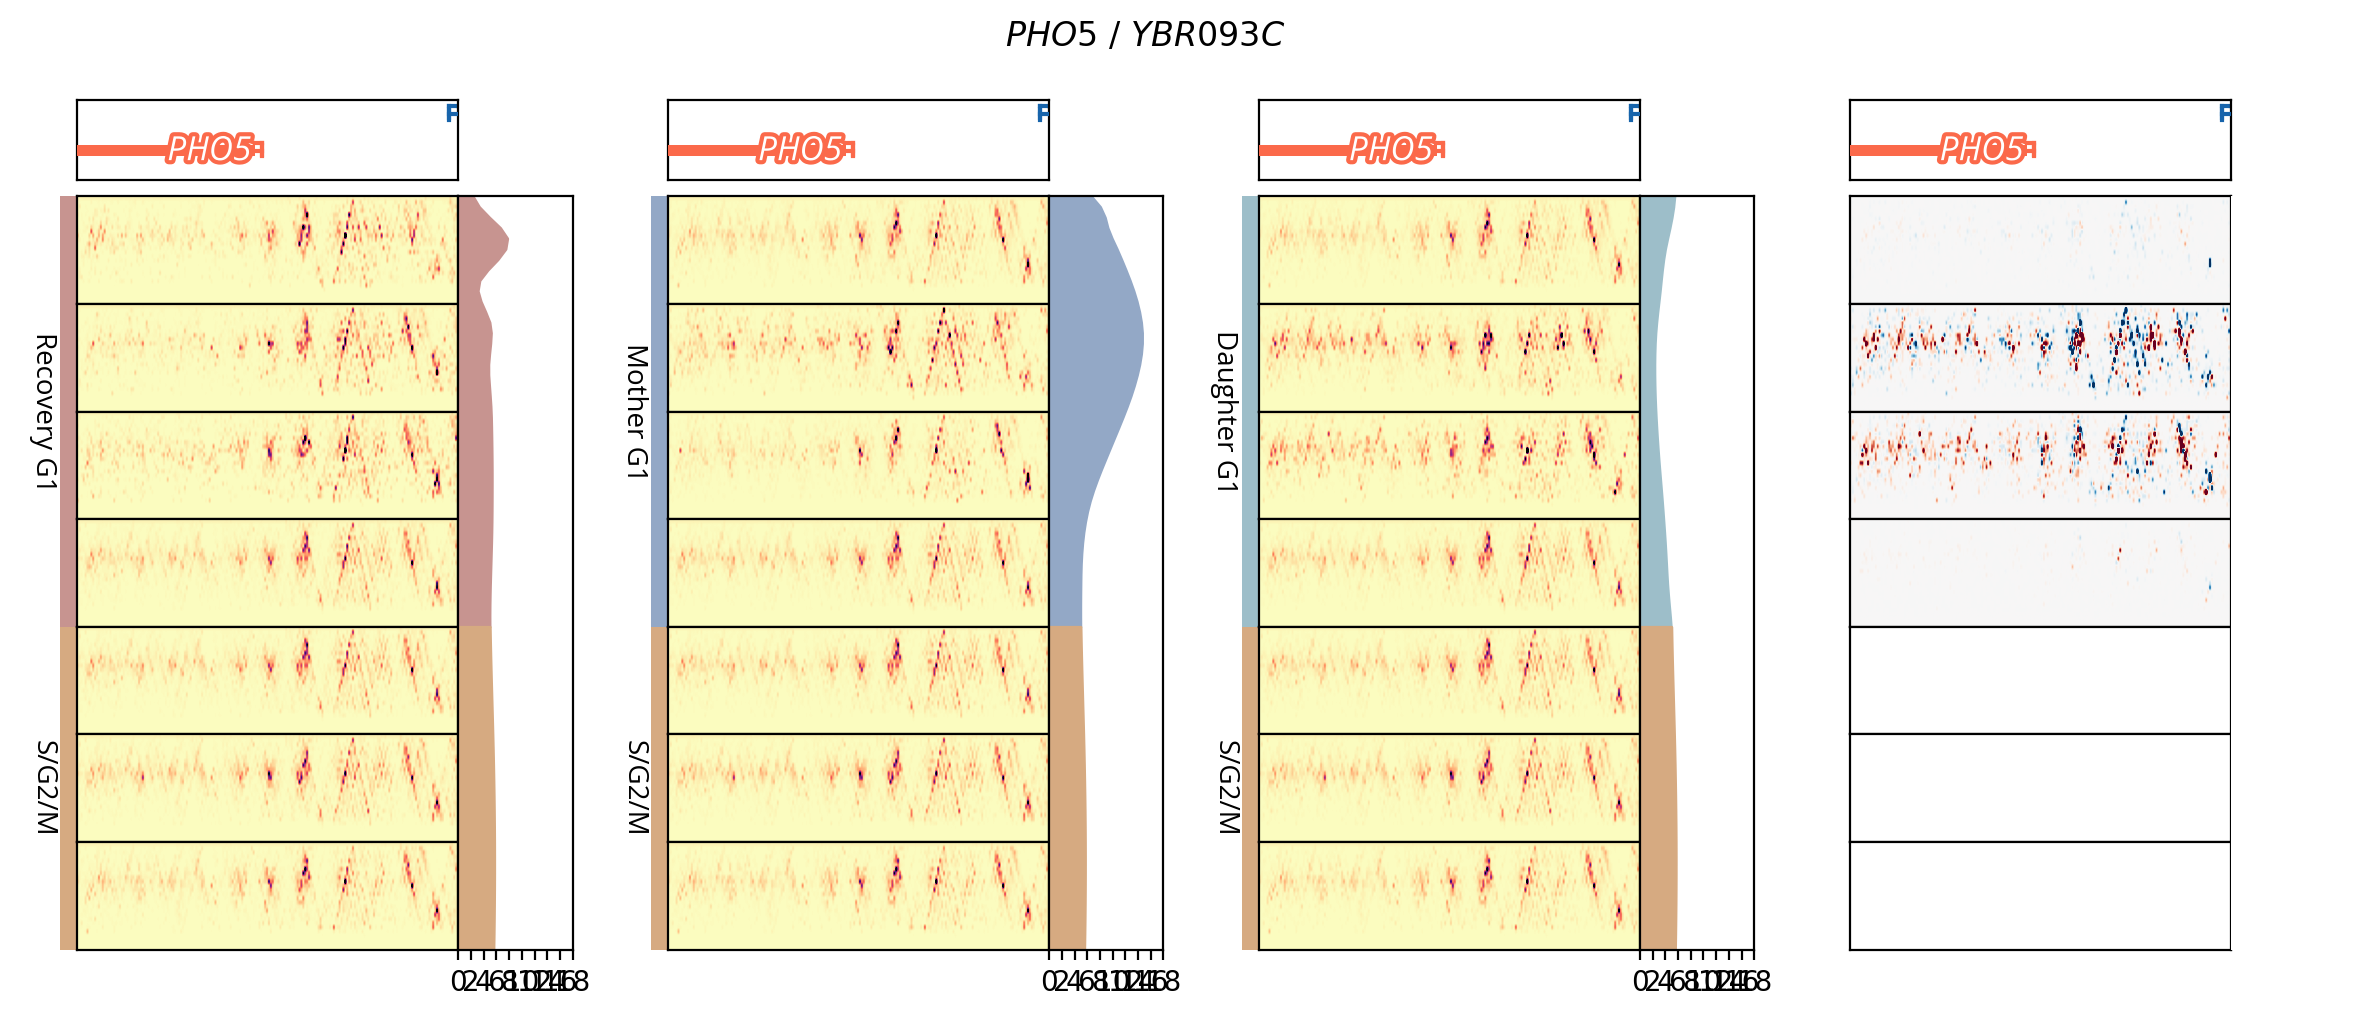

In [11]:
fig = genome_analysis.plot_gene('PHO5', config1, analysis)

In [12]:
from src.expression_promoter_shift_analysis import PromoterExpressionShiftAnalysis

# analysis and dg1 analysis are the objects that hold the tx and chromatin data
# they should be renamed
promoter_expression_shift_analysis = PromoterExpressionShiftAnalysis(analysis, 
                                                                     dg1_analysis, config1)

Using a threshold of 1.1
  429 post G1 expressed genes
  93 Mother G1 specific genes
  373 Daughter G1 specific genes
  90 Mother and Daughter expressed genes
  4587 All others
  Total:  5572


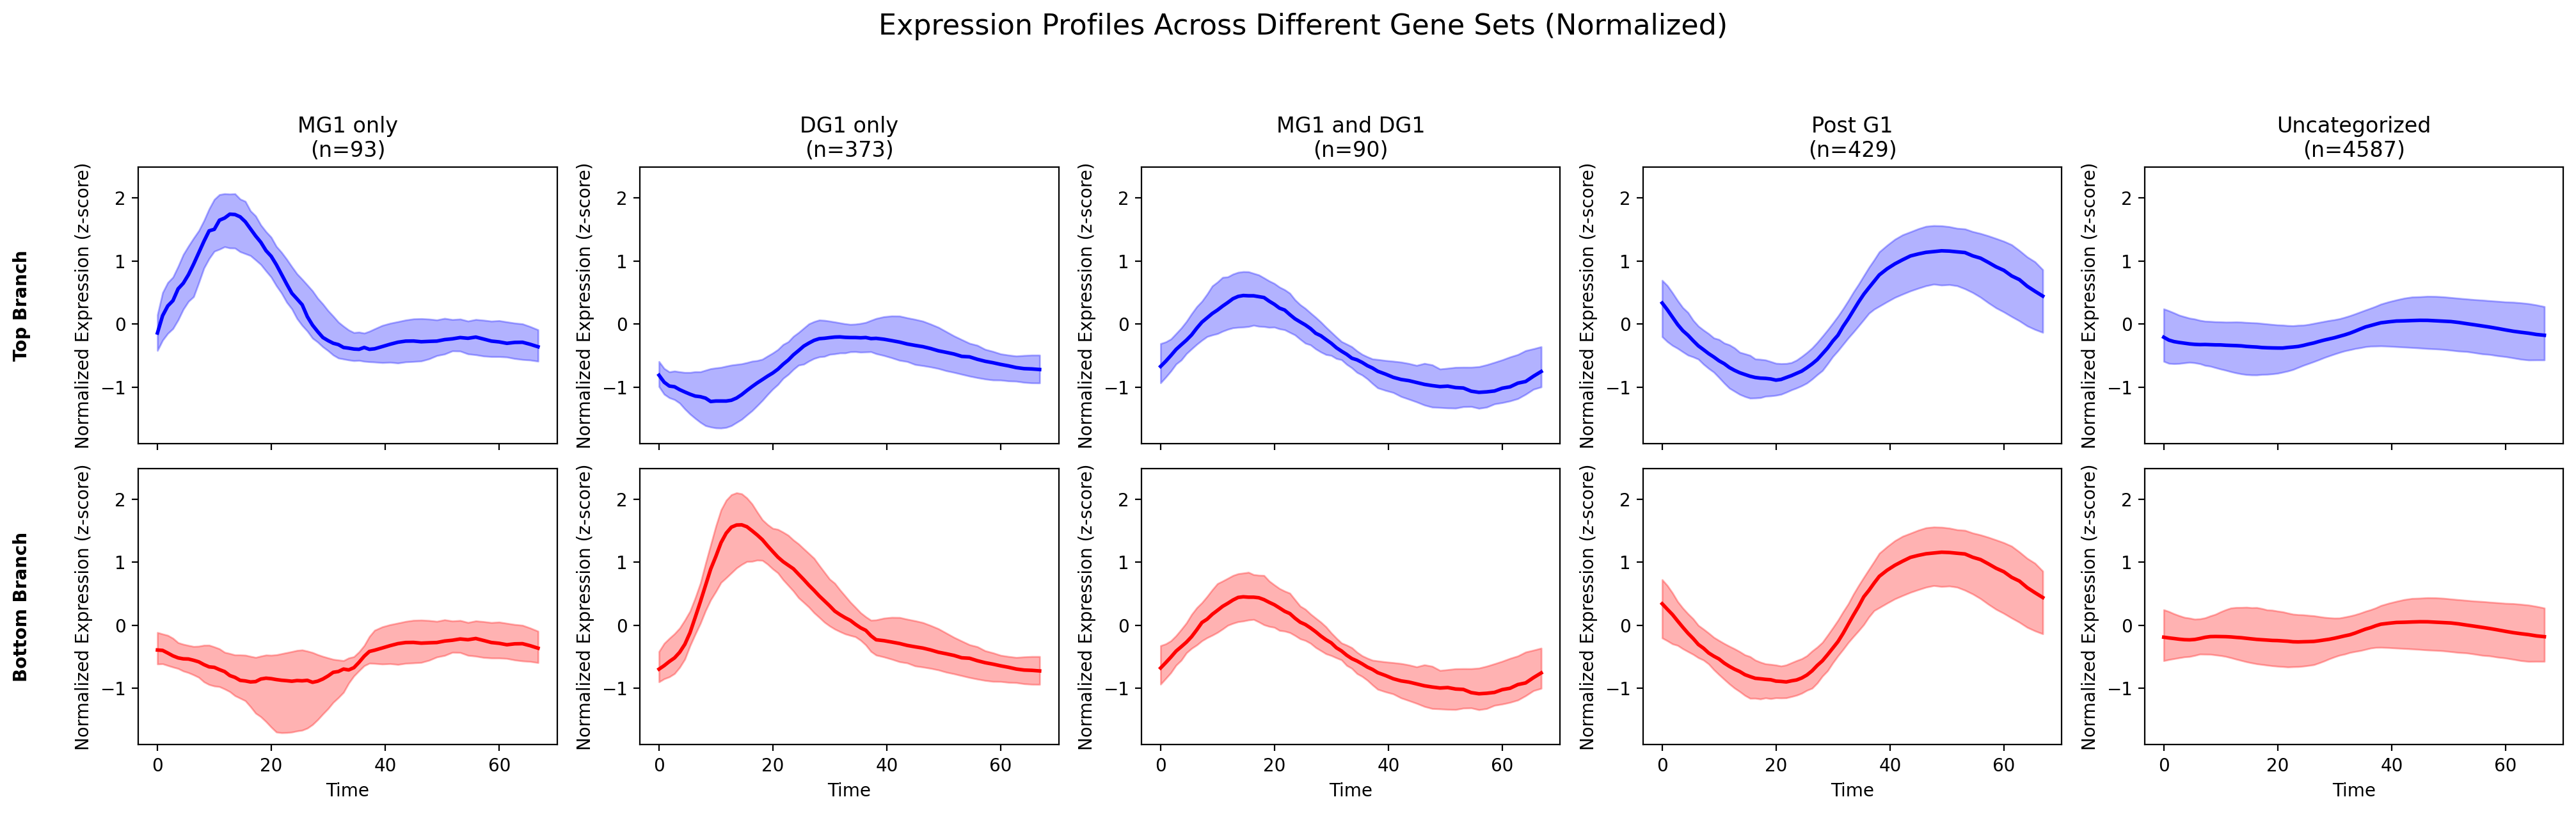

In [13]:
fig, axs = promoter_expression_shift_analysis.plot_expression_quantiles()

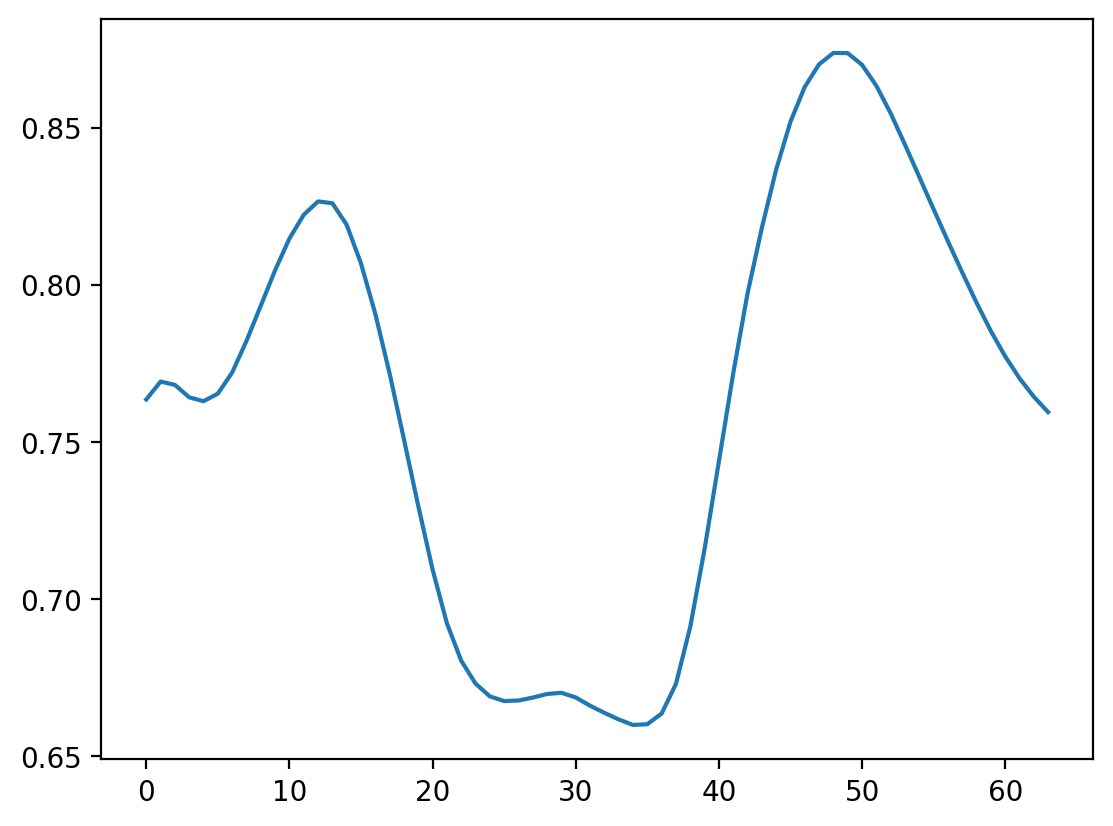

In [110]:
plt.plot(dg1_analysis.small_promoter_occupancies_df.loc[orfname][config1.b_indices()].values)

Percentile values for threshold (top/bottom): 0.14, 0.12


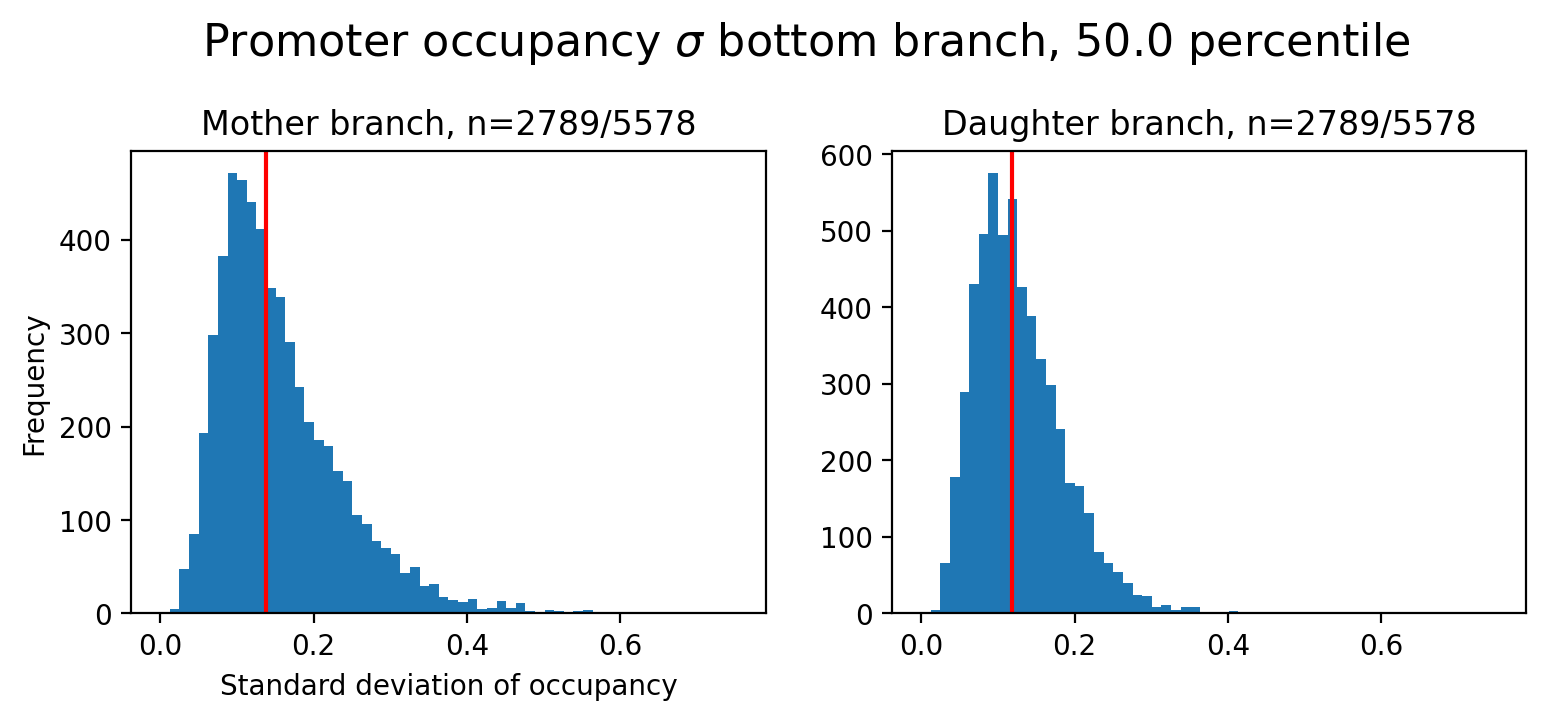

In [169]:
# We can remove this step, as it doesnt' have too much of a bearing on the result
promoter_expression_shift_analysis.compute_high_std_promoter_orfs_set()

In [123]:
promoter_expression_shift_analysis.filter_gene_subsets_for_high_std()

todo: Removing filter step, for simplicity, as it does not change the result. The same trend occurs for the activator and repressor classification


In [418]:
promoter_expression_shift_analysis.compute_promoter_expression_correlations(debug=False)

00:05:34.926


(array([295., 298., 800., 638., 838., 888., 356., 645., 344., 470.]),
 array([-32. , -25.6, -19.2, -12.8,  -6.4,   0. ,   6.4,  12.8,  19.2,
         25.6,  32. ]),
 <BarContainer object of 10 artists>)

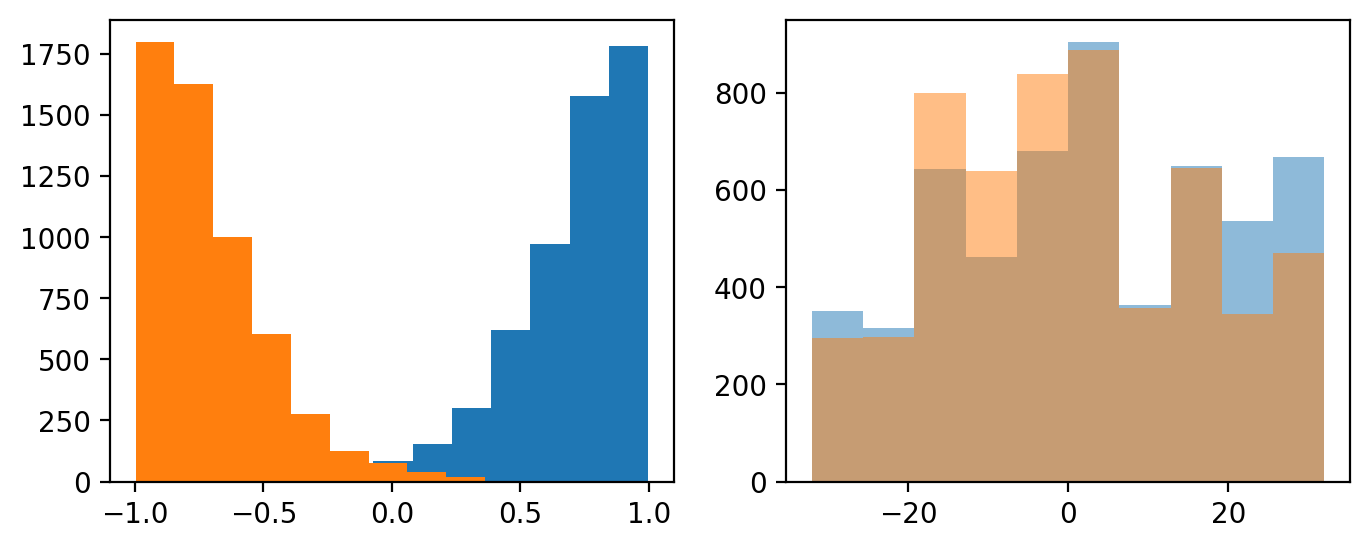

In [575]:
mother_results = promoter_expression_shift_analysis.correlation_calculator.results['mother']
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.hist(mother_results.local_max_corr)
plt.hist(mother_results.local_min_corr)

plt.subplot(1, 2, 2)
plt.hist(mother_results.local_max_shift, alpha=0.5)
plt.hist(mother_results.local_min_shift, alpha=0.5)

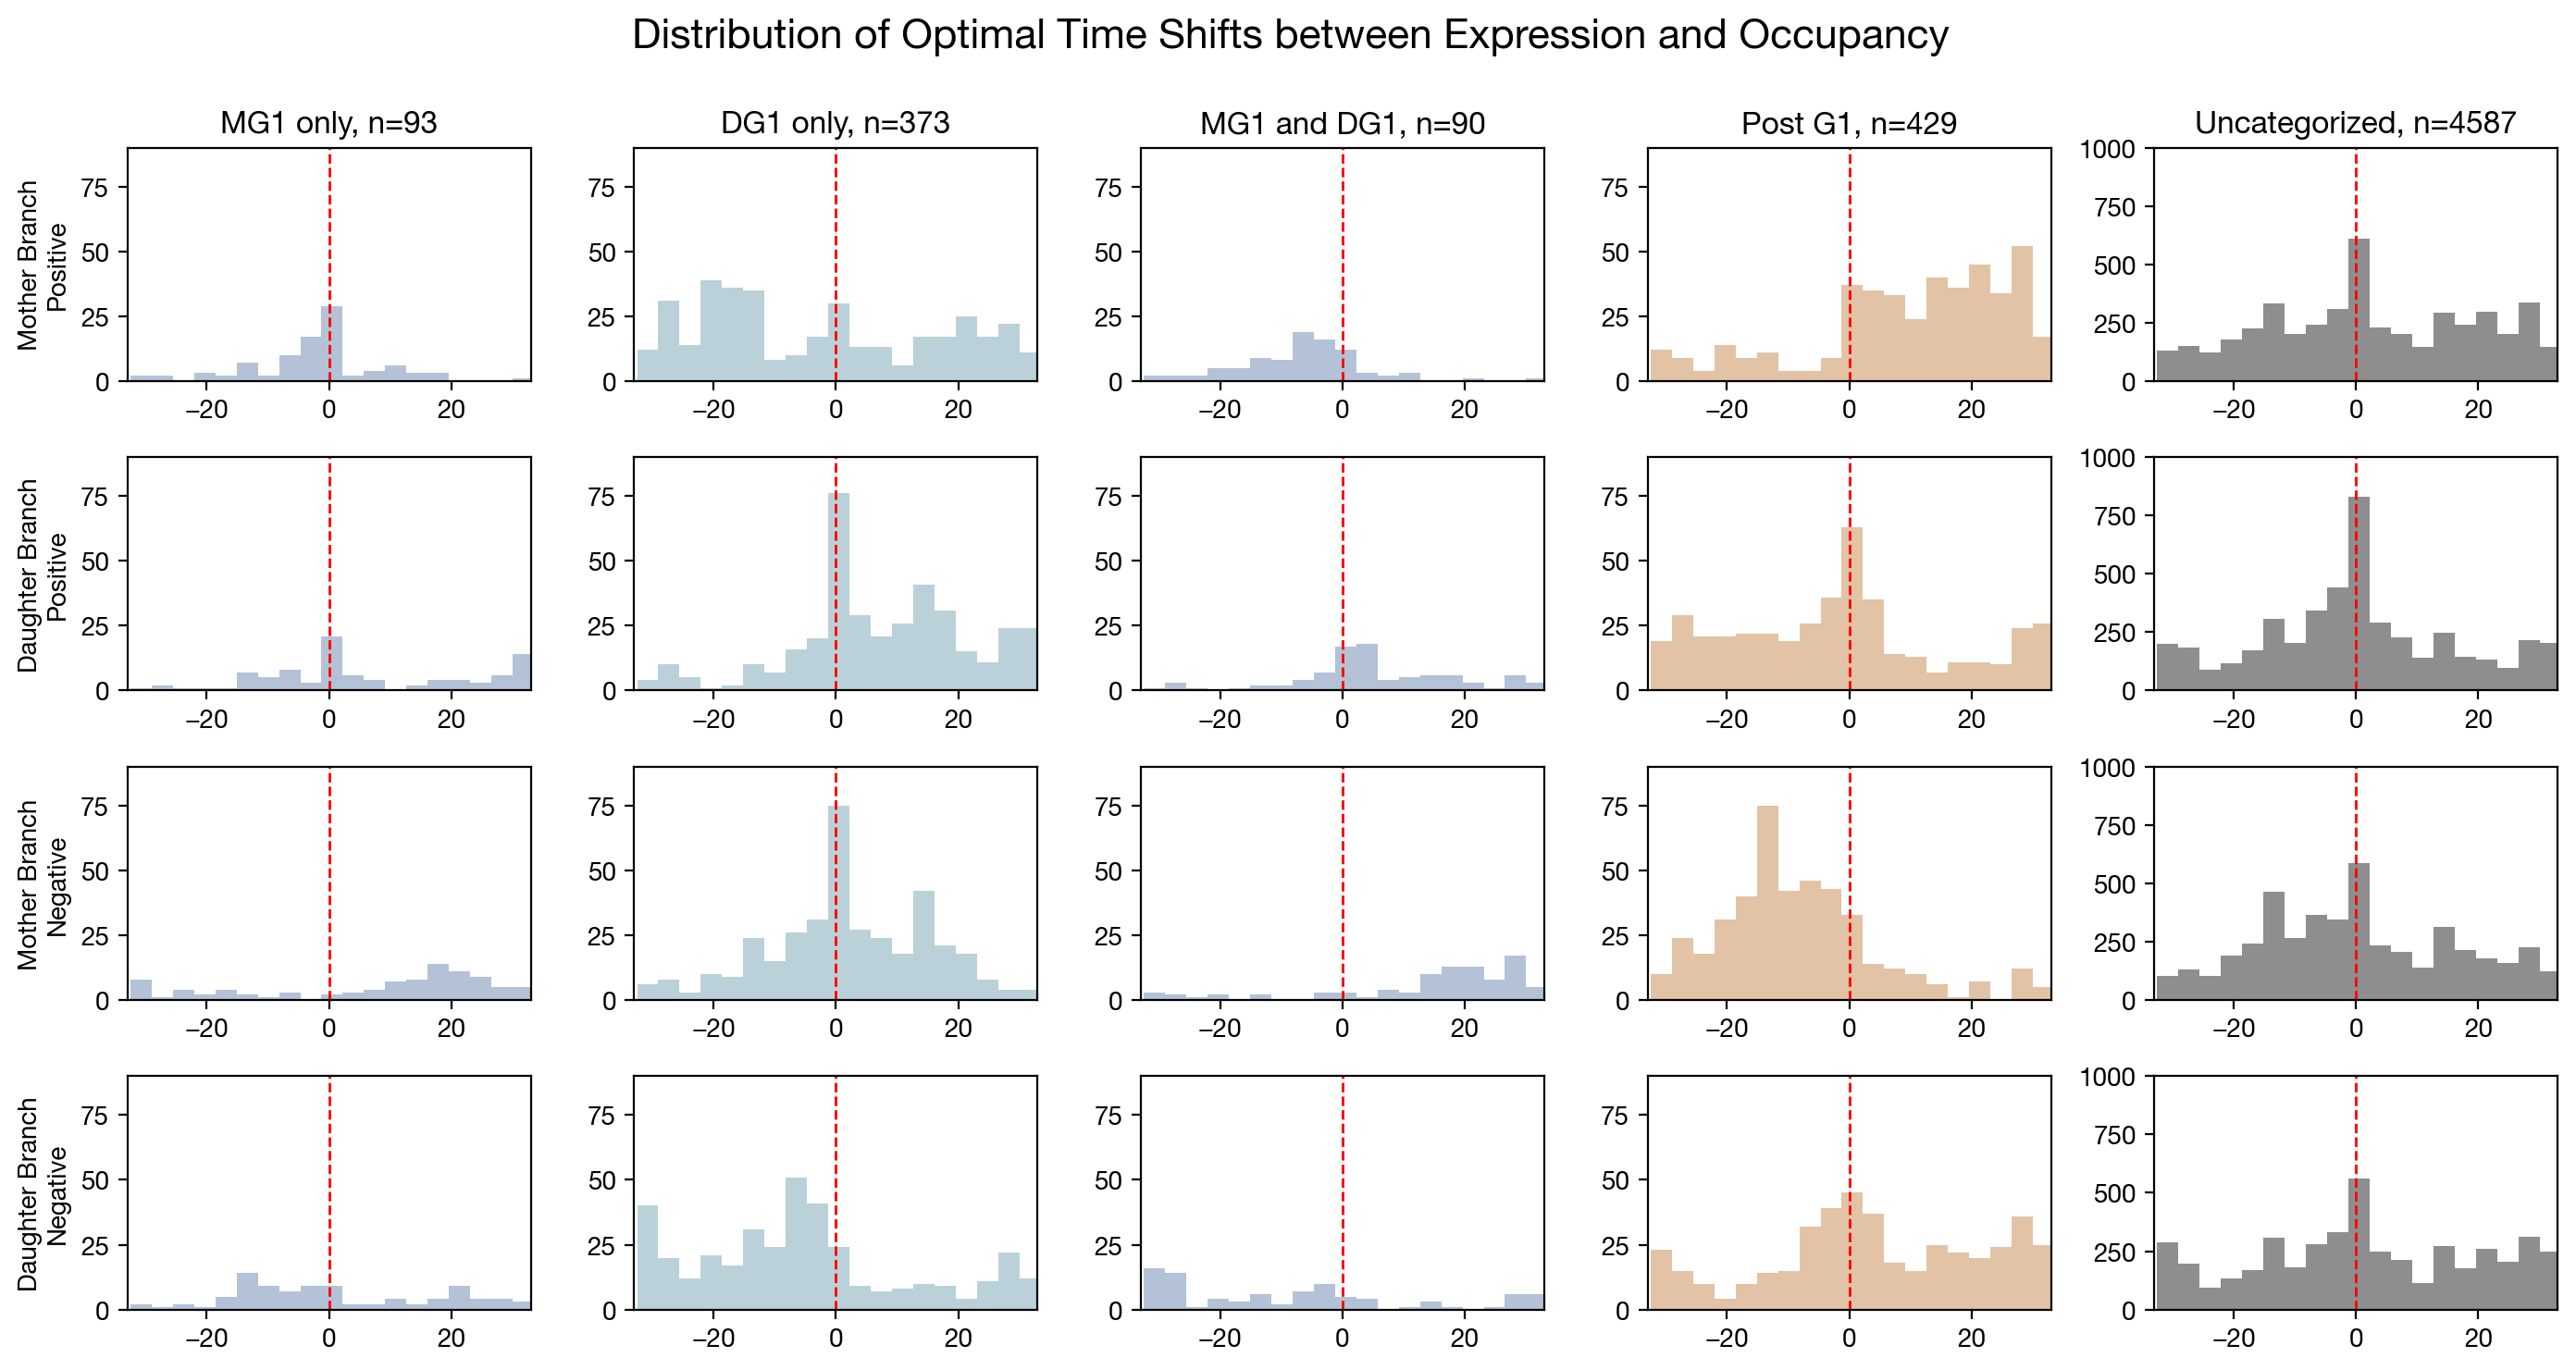

In [578]:
fig = promoter_expression_shift_analysis.correlation_calculator\
    .plot_optimal_shift_distributions(promoter_expression_shift_analysis.t_filtered_gene_subsets)

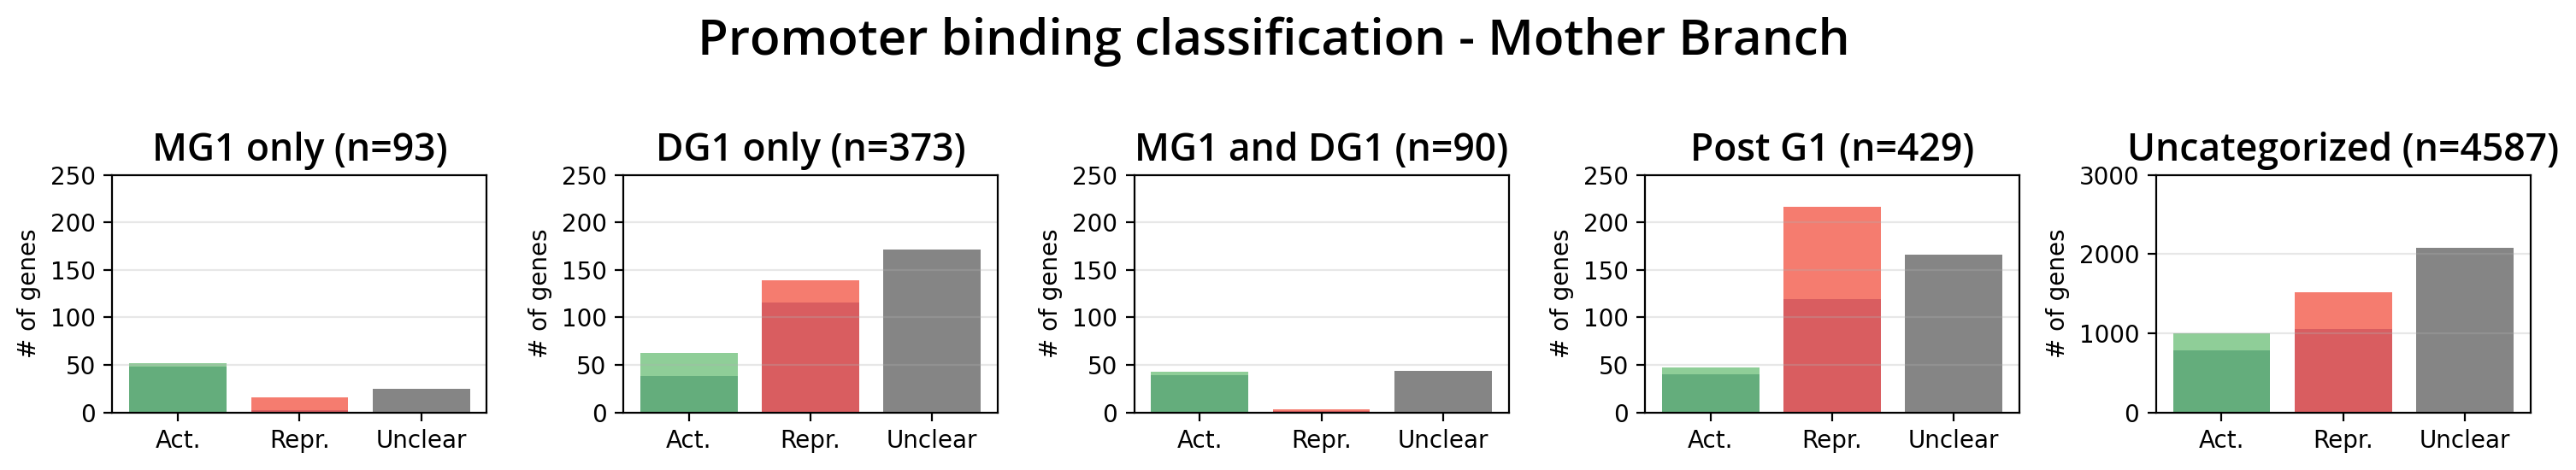

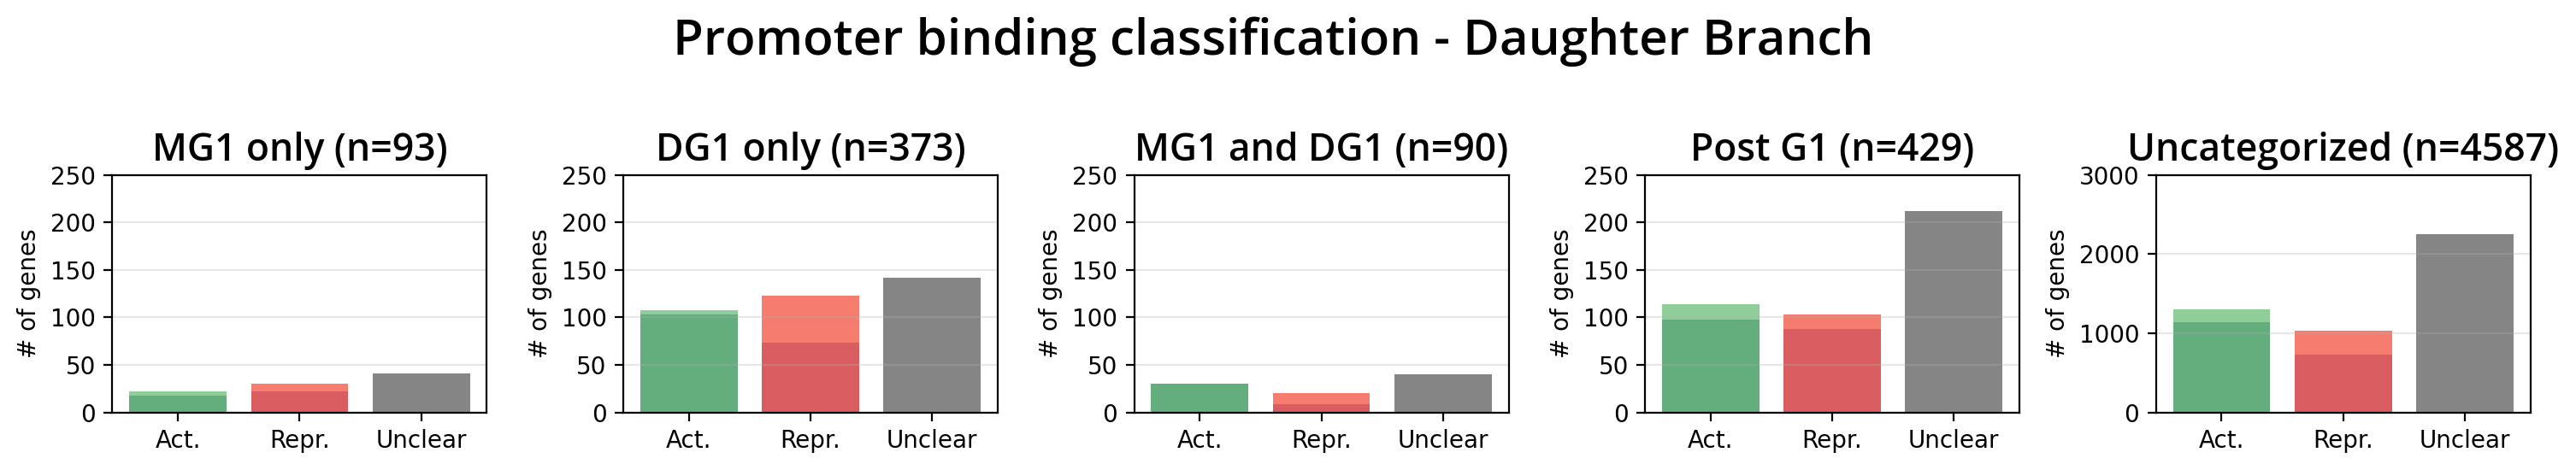

In [619]:
fig = promoter_expression_shift_analysis.correlation_calculator\
    .plot_regulation_type_bar_counts("mother", 
    promoter_expression_shift_analysis.t_filtered_gene_subsets)
fig = promoter_expression_shift_analysis.correlation_calculator\
    .plot_regulation_type_bar_counts("daughter", 
    promoter_expression_shift_analysis.b_filtered_gene_subsets)

In [421]:
# Analysis of repressed postG1 genes
postg1_genes = promoter_expression_shift_analysis.t_filtered_gene_subsets['Post G1']
mother_results = promoter_expression_shift_analysis.correlation_calculator.results['mother']
postg1_results = mother_results.loc[postg1_genes]
postg1_repressors = postg1_results[postg1_results['local_regulation_type'] == 'REPRESSION_DIRECT']

for g in postg1_repressors.join(genes[['gene']]).gene.values:
    print(g)

# Enriched for spindle pole assembly


In [422]:
orfname = 'YJR078W' # misclassified, needs to be a repressor on both branches
# the negative shift on the positive correlation is too far away, and the negative 
# correlation is a better signal for repression

orfname = 'CIN8'

In [560]:
selected_results = mother_results.loc[postg1_genes]\
    [mother_results.loc[postg1_genes].local_regulation_type == 'ACTIVATION_IMMEDIATE']
selected_results[selected_results.local_max_corr > 0.9]

,local_max_corr,local_max_shift,local_min_corr,local_min_shift,local_regulation_type
YDR224C,0.947668,-4,-0.808286,30,ACTIVATION_IMMEDIATE
YNL141W,0.940771,-5,-0.975106,28,ACTIVATION_IMMEDIATE
YGL184C,0.918068,2,-0.708566,-32,ACTIVATION_IMMEDIATE
YBR085W,0.941887,3,-0.941962,-29,ACTIVATION_IMMEDIATE
YML125C,0.983090,2,-0.994118,-29,ACTIVATION_IMMEDIATE
YBL029W,0.960879,2,-0.856785,-30,ACTIVATION_IMMEDIATE
YKR041W,0.989334,-4,-0.991233,28,ACTIVATION_IMMEDIATE
YNL012W,0.962851,2,-0.541472,-21,ACTIVATION_IMMEDIATE
YDR522C,0.932912,2,-0.836196,-25,ACTIVATION_IMMEDIATE
YOR012W,0.968477,4,-0.965346,-29,ACTIVATION_IMMEDIATE


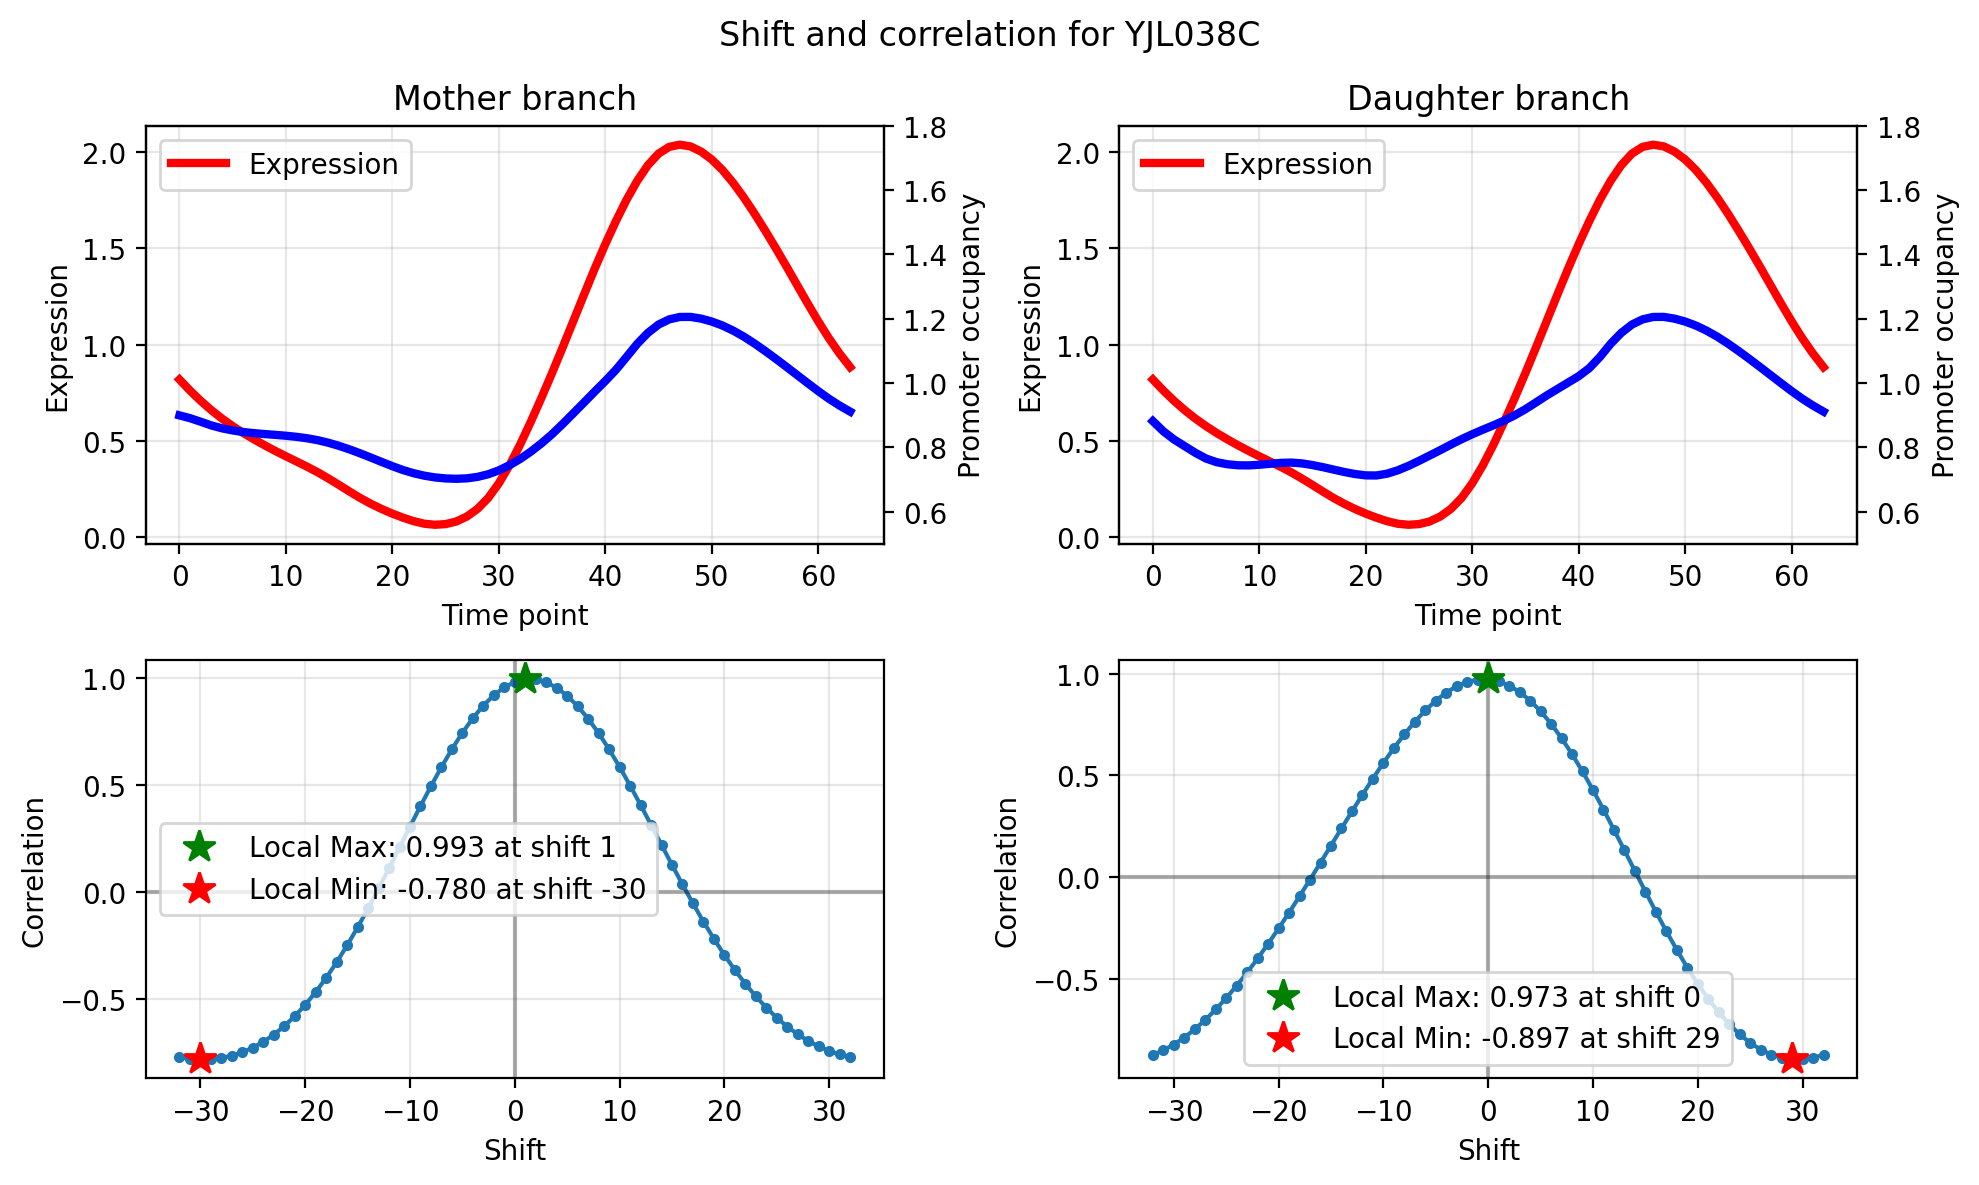

In [568]:
from src.sgd import get_orfname

orfname = 'YJL038C'
orfname = get_orfname(orfname)
fig = promoter_expression_shift_analysis.correlation_calculator\
    .plot_gene_correlation_with_local_optima(orfname)


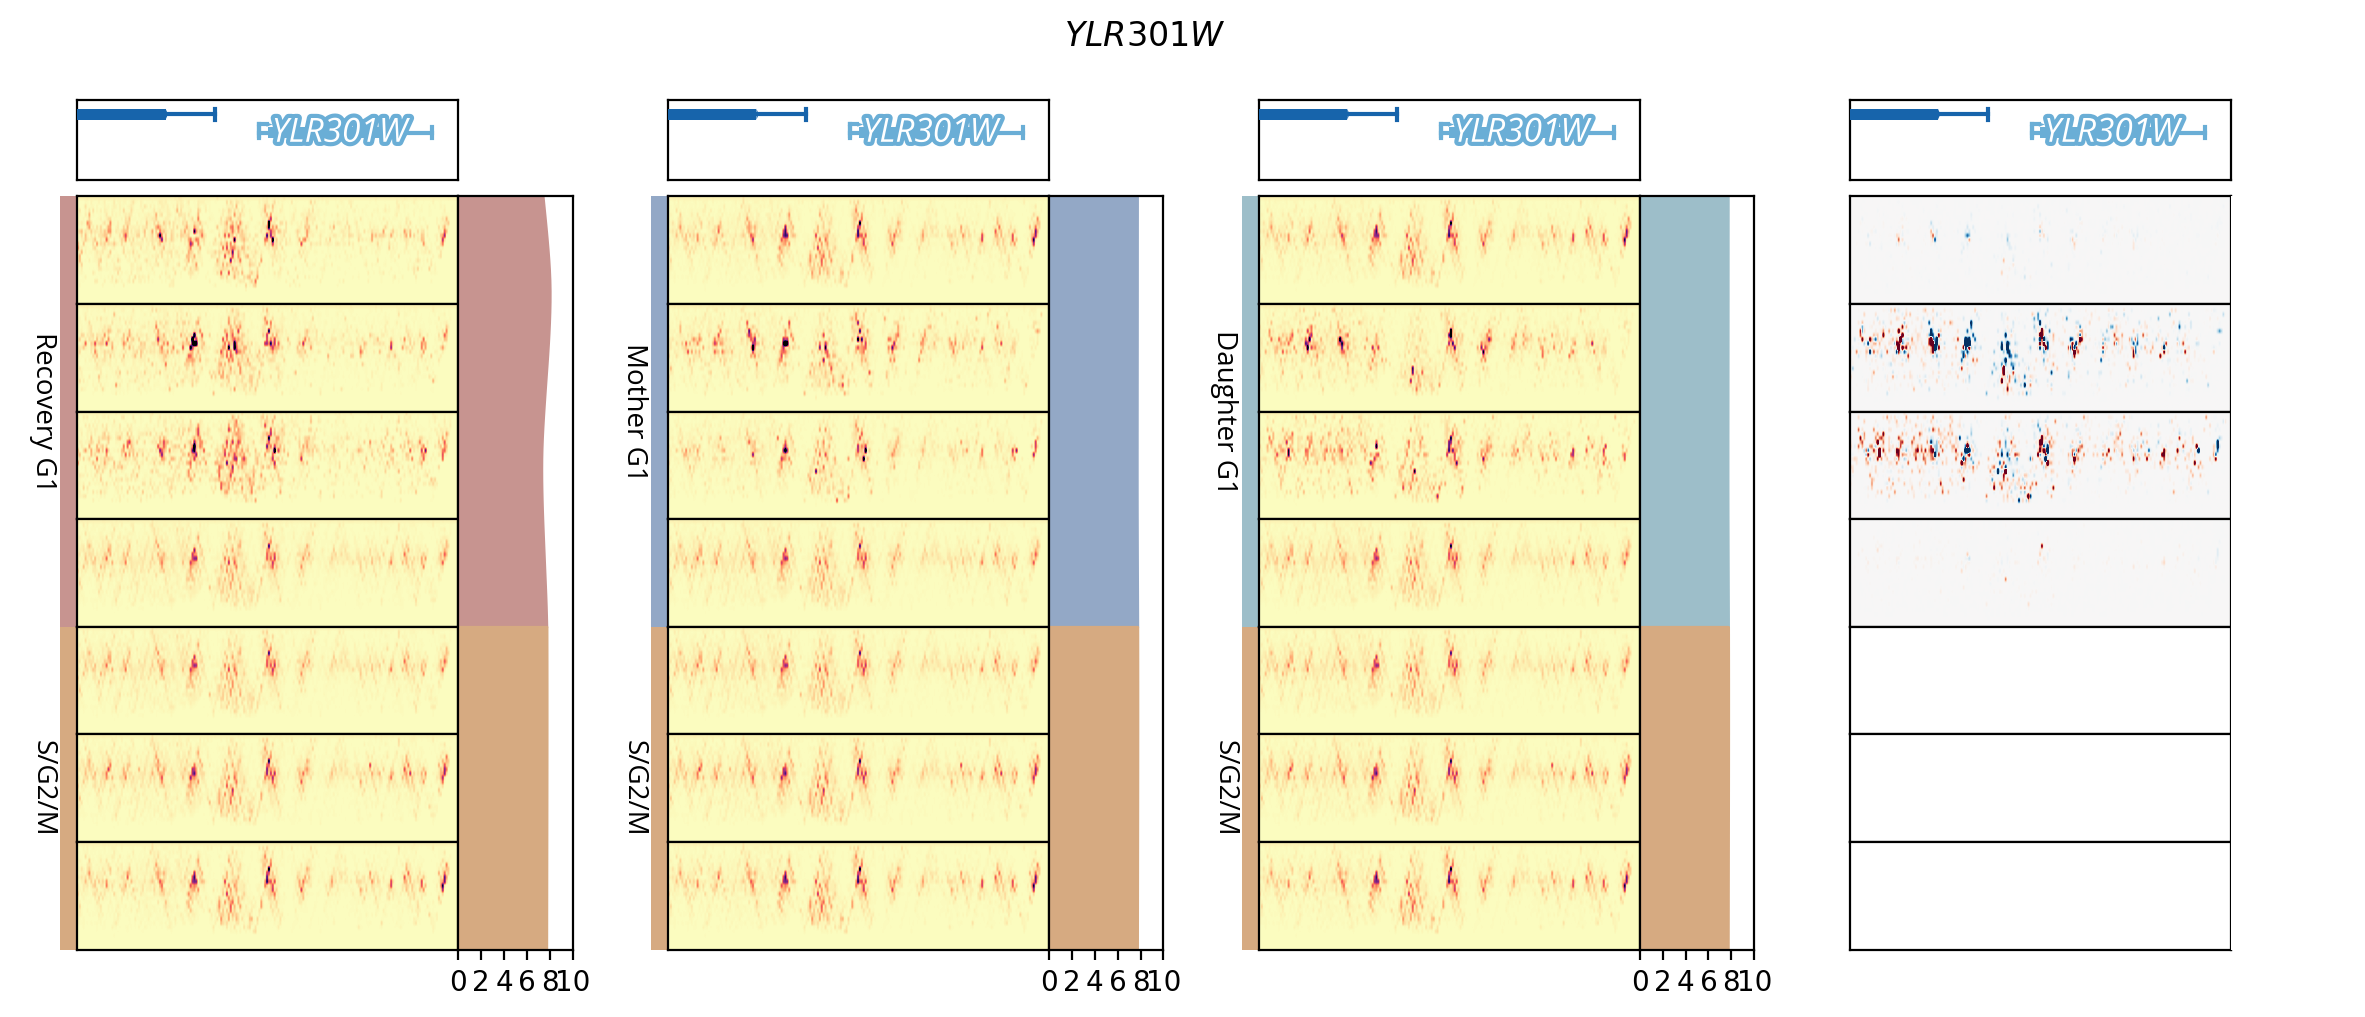

In [556]:
config1 = analysis.config1
fig = genome_analysis.plot_gene(orfname, config1, analysis)

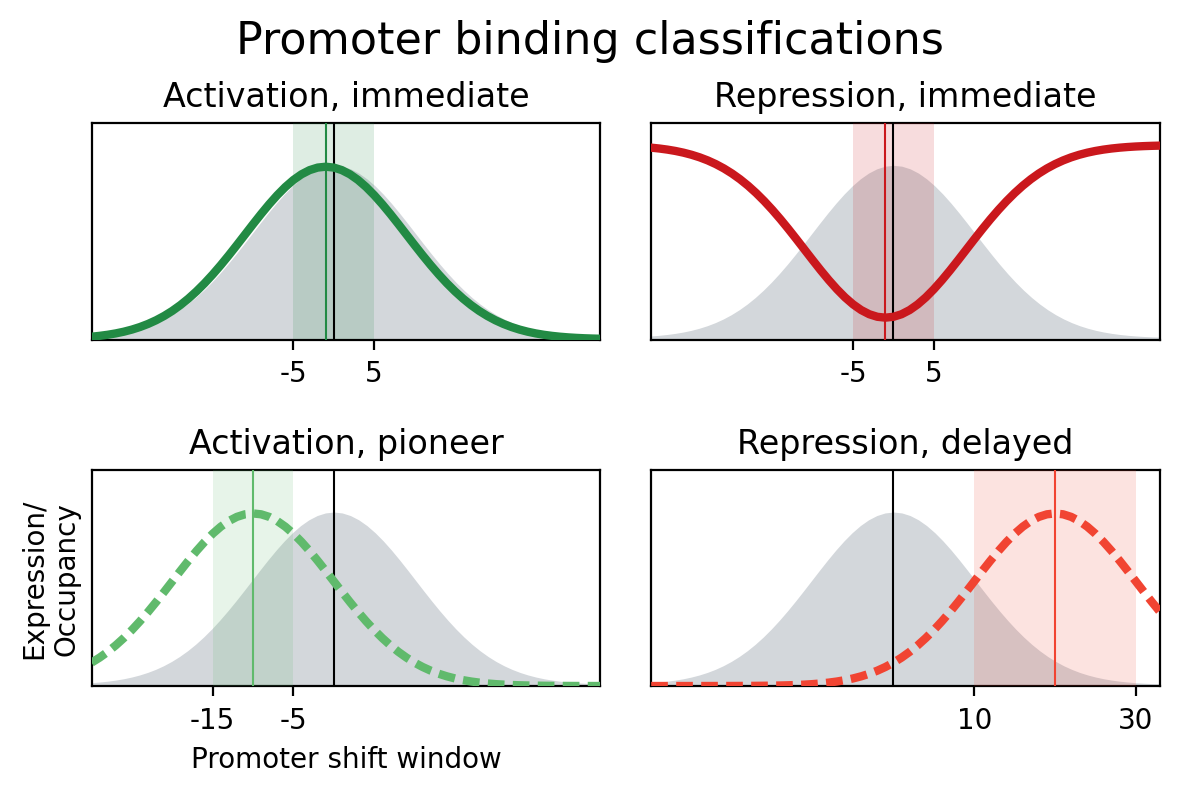

In [520]:
from src.chromatin_expression_optimal_shift import plot_binding_modalities

plot_binding_modalities(config1)


In [620]:
# Begin refactoring gene expression selection of genes using polar plot:

In [993]:
from src.peak_to_trough import compute_quantile_ptr_2d

def prep_polar_plot_data(t_expressions, g1_phase_key, eps):
    t_expressions = t_expressions.copy()
    t_expressions.columns = np.arange(len(t_expressions.columns))
    t_ptrs = compute_quantile_ptr_2d(t_expressions, eps=eps)
    t_peak_idx = t_expressions.idxmax(1)
    t_polar_data_df = pd.DataFrame({'peak_idx': t_peak_idx, 'ptr': t_ptrs},
                                  index=t_expressions.index)
    t_polar_data_df['phase'] = g1_phase_key
    t_polar_data_df.loc[t_polar_data_df.peak_idx >= 44, 'phase'] = 'postG1'

    return t_polar_data_df

def create_combined_ptr_data_set(gene_data, config1, q_threshold, eps):
    # Sort through the polar data and assign the genes into MG1, DG1, or postG1 based
    # on highest PTR
    b_polar_data_df = prep_polar_plot_data(gene_data[config1.b_indices()],
        'DG1', eps)
    t_polar_data_df = prep_polar_plot_data(gene_data[config1.t_indices()],
        'MG1', eps)

    # Then assign genes based on the highest ptr
    combined_polar_data_df = b_polar_data_df.copy()

    sel = b_polar_data_df.ptr > t_polar_data_df.ptr
    combined_polar_data_df.loc[sel, :] = b_polar_data_df.loc[sel, :]

    sel = b_polar_data_df.ptr < t_polar_data_df.ptr
    combined_polar_data_df.loc[sel, :] = t_polar_data_df.loc[sel, :]

    ptr_threshold = np.quantile(combined_polar_data_df.ptr, q=q_threshold)
    
    below_thresh = combined_polar_data_df[combined_polar_data_df.ptr < ptr_threshold]
    above_thresh = combined_polar_data_df[combined_polar_data_df.ptr >= ptr_threshold]

    combined_polar_data_df = combined_polar_data_df.copy()
    combined_polar_data_df['bin'] = combined_polar_data_df.phase
    combined_polar_data_df.loc[below_thresh.index, 'bin'] = 'Not cell cycle'
    combined_polar_data_df.bin.value_counts()

    return combined_polar_data_df, ptr_threshold


In [1453]:
tx_qval = 0.95
sm_qval = 0.95

expression_combined_polar_data_df, tx_ptr_threshold = create_combined_ptr_data_set(
    analysis.deconvolved_genes_F, config1, tx_qval, eps=1)

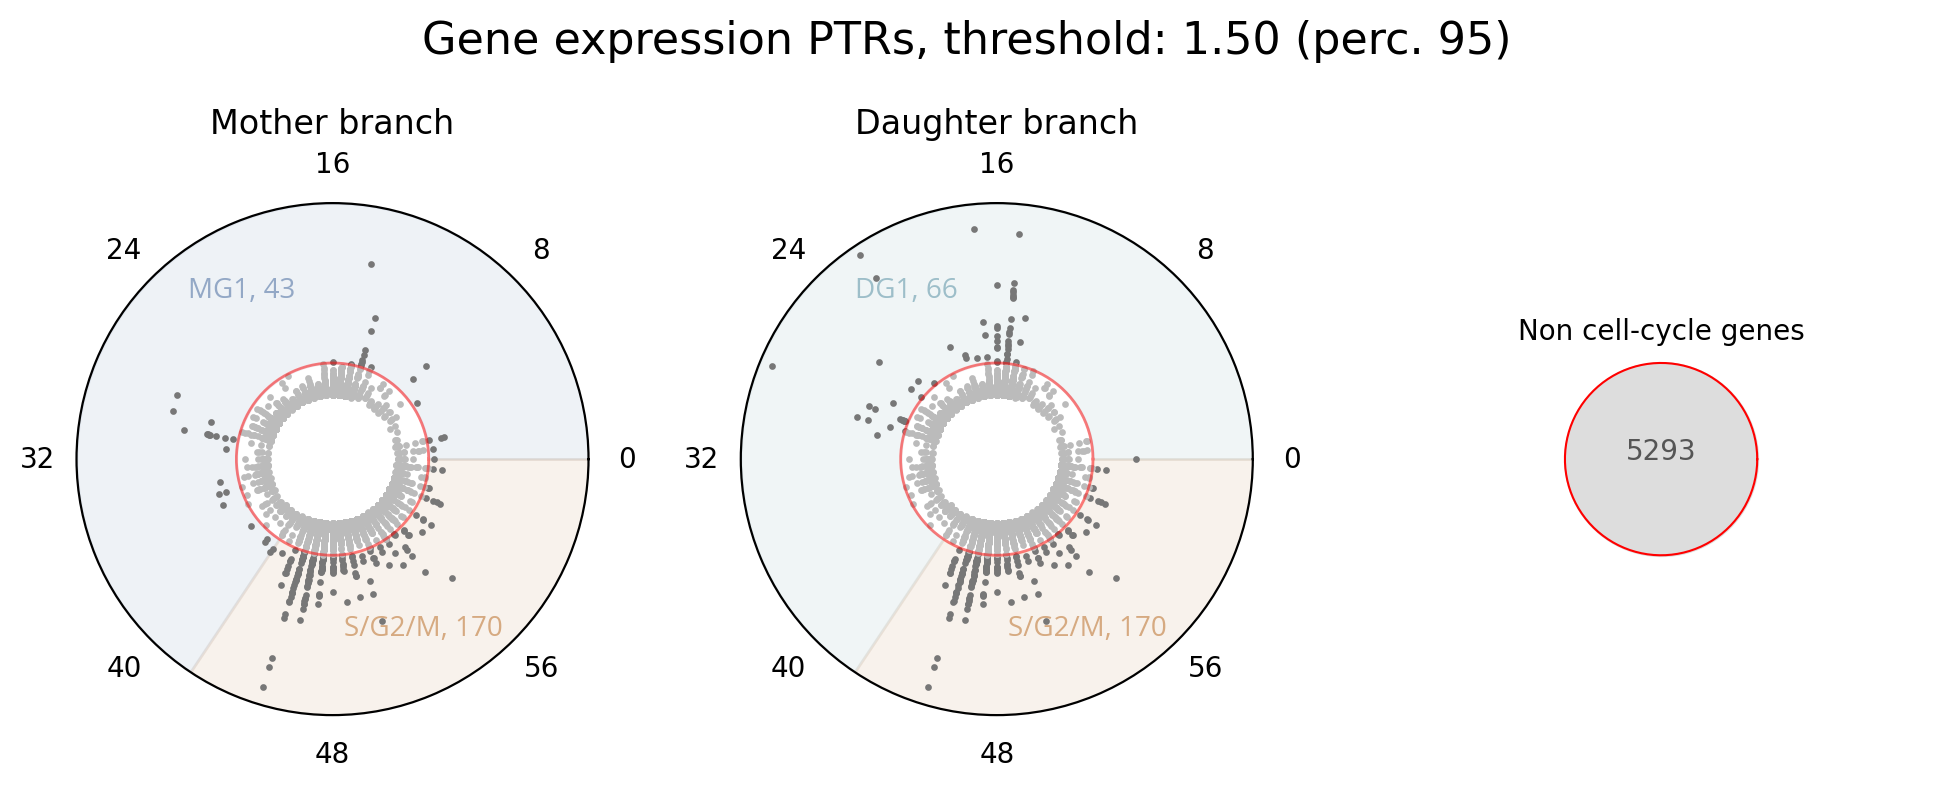

In [1518]:
from src.polar_plotter import PolarPlot, plot_polar_branches_data

plot_polar_branches_data(expression_combined_polar_data_df,
                        tx_ptr_threshold, tx_qval, "Gene expression", (0, 4))


In [1455]:
# Let's try the same for the small fragments data
small_combined_polar_data_df, sm_ptr_threshold = create_combined_ptr_data_set(
    dg1_analysis.small_promoter_occupancies_df, config1,
    sm_qval, eps=1)


Text(0.5, 0, 'PTR')

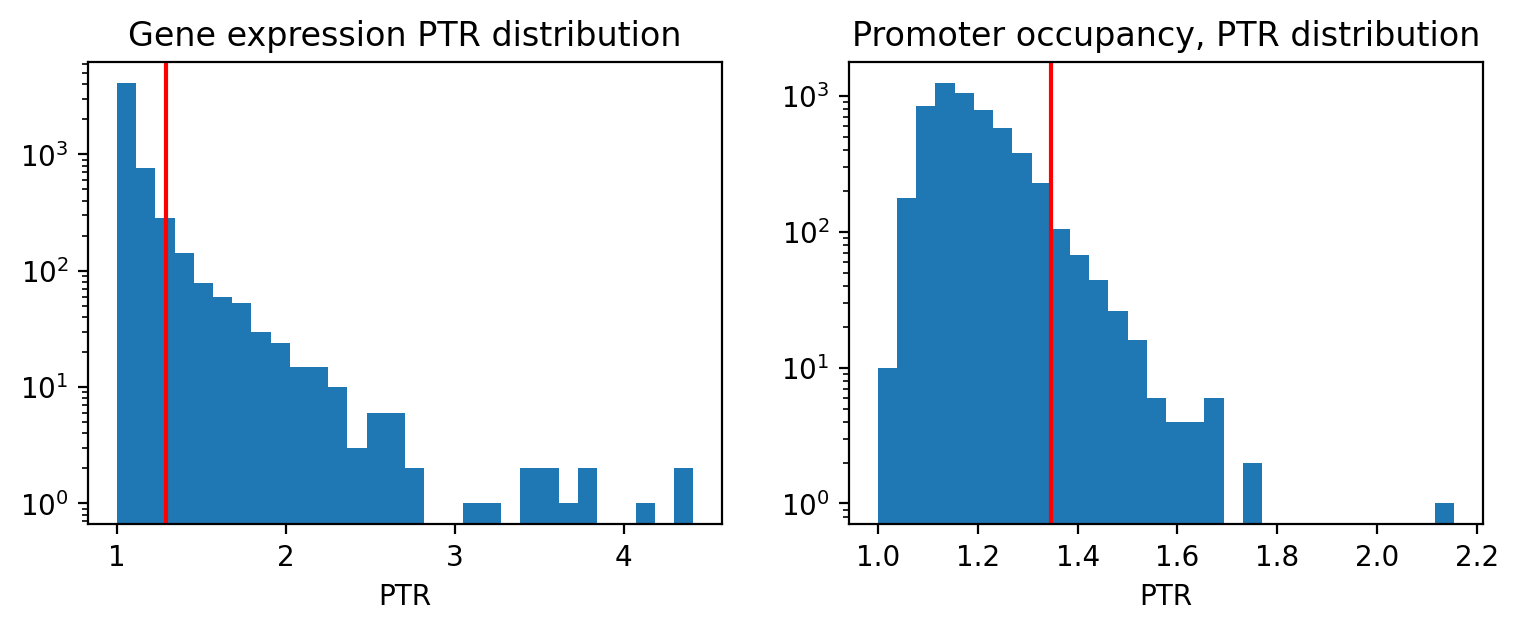

In [1456]:
plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.hist(combined_polar_data_df.ptr, bins=30)
plt.yscale('log')
plt.axvline(ptr_threshold, c='red')
thresholded_genes = combined_polar_data_df[combined_polar_data_df.ptr > ptr_threshold]
num_threshold = len(thresholded_genes)
plt.title(f"Gene expression PTR distribution")
plt.xlabel('PTR')

plt.subplot(1, 2, 2)
plt.hist(small_combined_polar_data_df.ptr, bins=30)
plt.axvline(sm_ptr_threshold, c='red')
plt.title("Promoter occupancy, PTR distribution")
plt.yscale('log')
plt.xlabel('PTR')

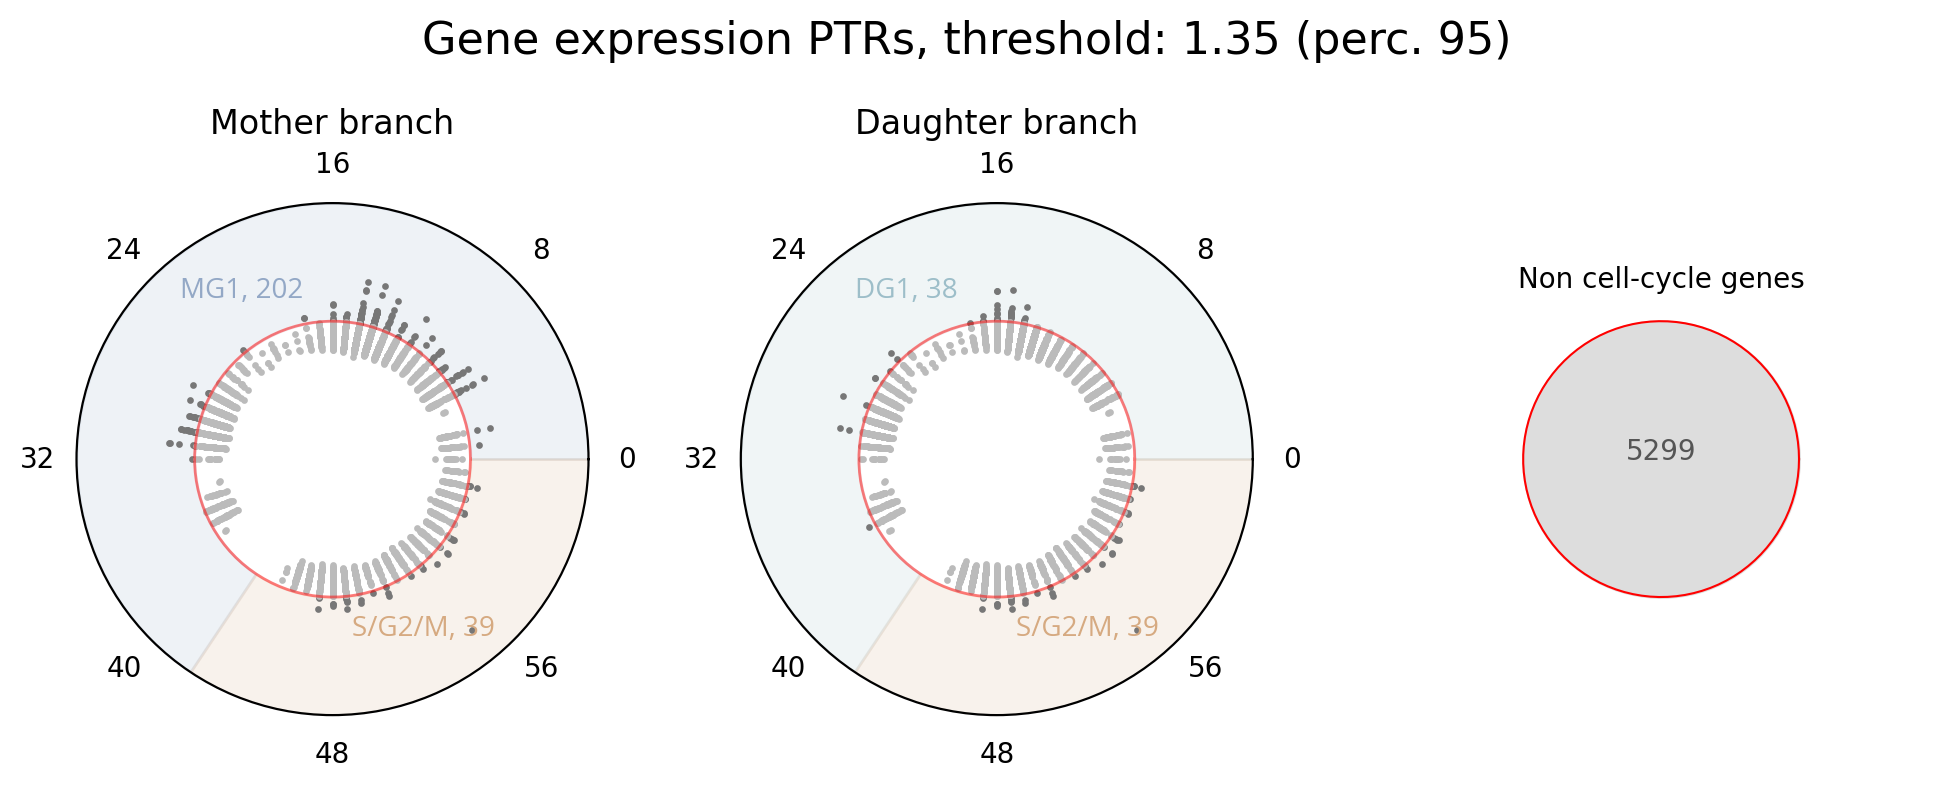

In [1519]:
plot_polar_branches_data(small_combined_polar_data_df,
                        sm_ptr_threshold, sm_qval, "Gene expression", (0, 2.5))


In [1458]:
from src.expression_chromatin_plots import categorize_cell_cycle_genes, \
    plot_cell_cycle_comparison

In [1459]:
# Categorize genes
results = categorize_cell_cycle_genes(
    expression_combined_polar_data_df, 
    small_combined_polar_data_df
)

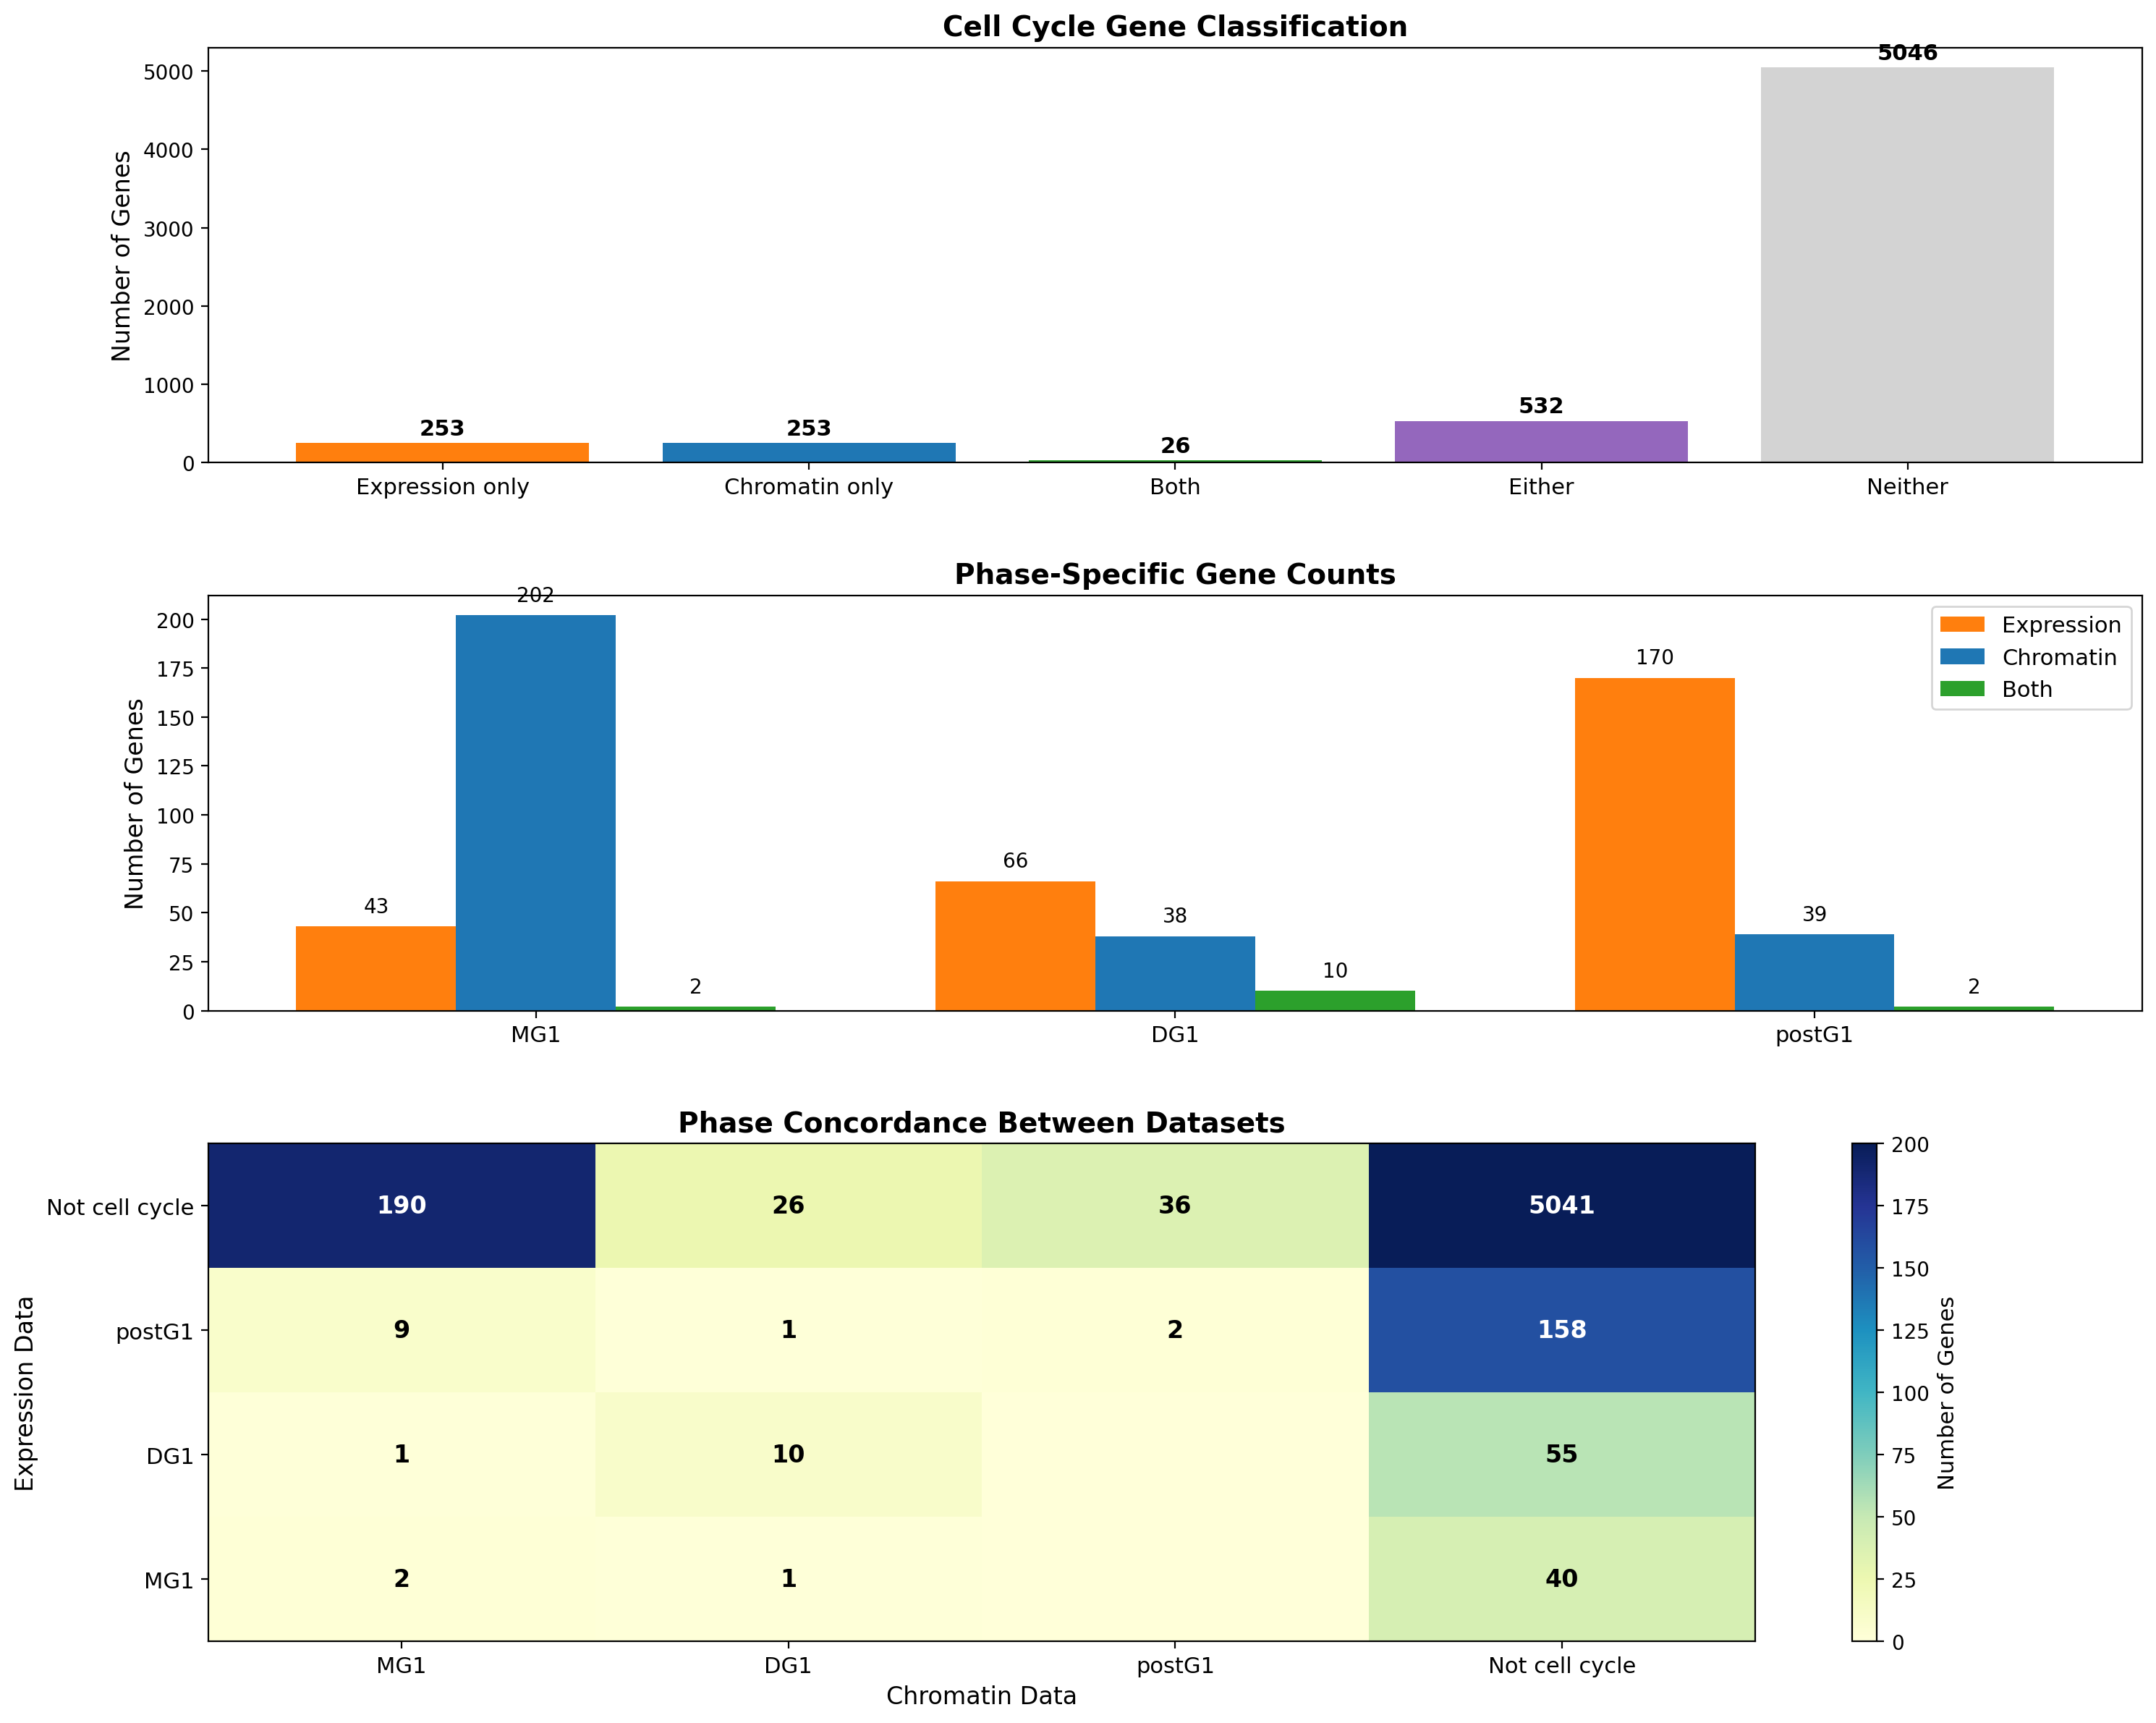

In [1460]:
fig = plot_cell_cycle_comparison(results)

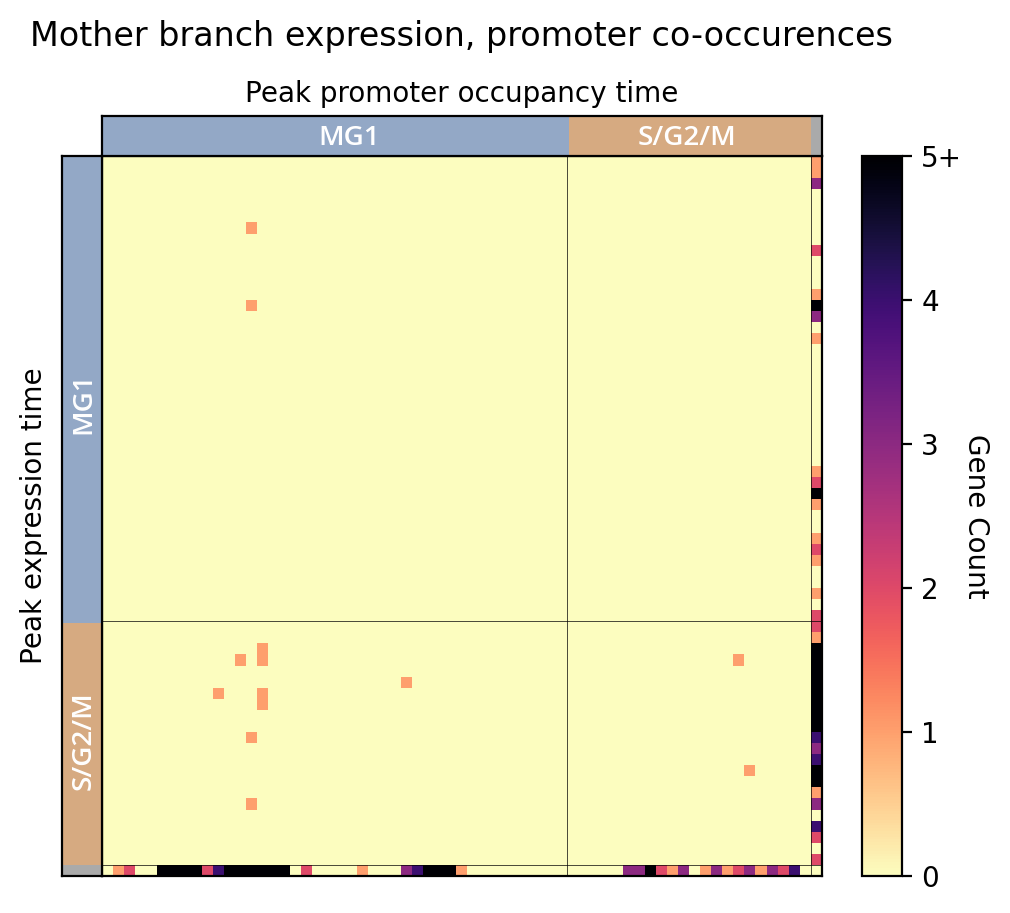

In [1461]:
from src.heatmap_counts import plot_cooccurences

plot_cooccurences(expression_combined_polar_data_df, small_combined_polar_data_df,
                 branch='mother')

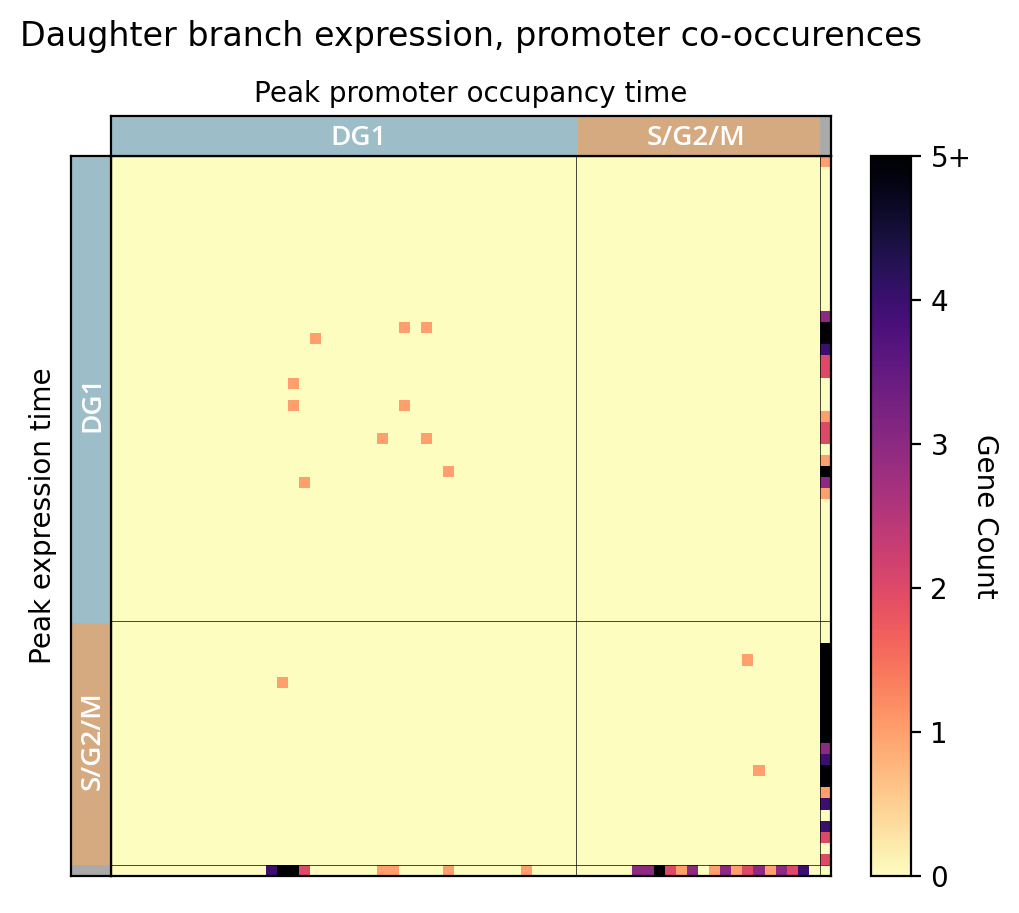

In [1462]:
from src.heatmap_counts import plot_cooccurences

plot_cooccurences(expression_combined_polar_data_df, small_combined_polar_data_df,
                 branch='daughter')